In [1]:
# not sure all these are needed. Can curate these at some point.
import copy

# import itertools
import random
import sys
import tempfile
import time
from sys import stdout

import ampal
import matplotlib.pyplot as plt

# import openmmtools
import numpy
import simtk.openmm as mm
from ampal.geometry import Quaternion, angle_between_vectors, dihedral, distance
from isambard import modelling, specifications
from simtk import unit
from simtk.openmm import app, vec3

%matplotlib inline

In [2]:
#this could use a different distance function (just 3D pythagoras), but the isambard one is fast
def calc_rmsd(frag1, frag2):
    """Returns the maximum distance between a pair of atoms in equivalent sets.

    Parameters
    ----------
    frag1: Polypeptide or Residue
        Reference section of protein for alignment.
    frag2: Polypeptide or Residue
        Target section of protein for alignment.

    Returns
    -------
    max_distance: float
        Maximum distance between a pair of like atoms.
    """
    frag1_atoms = frag1.backbone.get_atoms()
    frag2_atoms = frag2.backbone.get_atoms()
    return (0.25 * sum([distance(x, y) for x, y in zip(frag1_atoms, frag2_atoms)]))**0.5

In [3]:
#this is currently borked. Messes up coords if reaches max attempts
# builds a macrocycle by starting with random phi and psi angles, then mutating them till the ends overlap
# will build a _really_ shitty macrocyclic peptide, but that's sort of the point.
# wildly inefficient and unoptimised etc but whatever
def rand_mac(res, max_iter=20000, max_attempts=5, max_rmsd=0.05):
    initial_phi_psi = [[180, random.uniform(-180, 180), random.uniform(-180, 180)] for x in range(res)]
    best_angles = initial_phi_psi[:]
    test_model = specifications.TAPolypeptide([initial_phi_psi[-1]]+initial_phi_psi+initial_phi_psi[0:2])
    best_rmsd = calc_rmsd(test_model[1], test_model[-2])
    print(f"Starting rmsd is {best_rmsd}")
    cached_tries = []
    attempts = 0
    i = 0
    while best_rmsd > max_rmsd and i < max_iter:
        working_angles = copy.deepcopy(best_angles)
        for j in range(random.randint(2,6)): #might be better with just pairs of angles?
            working_angles[random.choice(range(len(initial_phi_psi)))][random.choice(range(1,3))] += random.gauss(0,0.5*best_rmsd)

        test_model = specifications.TAPolypeptide([working_angles[-1]] + working_angles+working_angles[0:2])
        #think this is ok in terms of building the C-terminus as we build two extra residues at C
        new_rmsd = calc_rmsd(test_model[1], test_model[-2])
        if (new_rmsd < best_rmsd) or (random.random() < 0.005): 
            best_angles = copy.deepcopy(working_angles)
            best_rmsd = new_rmsd
        if not(i % 100):
            sys.stdout.write(f"\rAt iter {i} best rmsd is {best_rmsd})")
            sys.stdout.flush()
        i += 1
        if i == max_iter:
            print(f'\nManaged only rmsd of {best_rmsd}: resampling!')
            cached_tries.append((best_angles, best_rmsd))
            if attempts == max_attempts:
                cached_tries.sort(key=lambda x: x[1])
                print(f"Ran out of attempts, best rmsd was {cached_tries[0][1]}")
                return(cached_tries[0][0])
#             initial_phi_psi = [[180, random.uniform(-180, 180), random.uniform(-180, 180)] for x in range(res)]
#             best_angles = initial_phi_psi[:]
            for k in range(len(best_angles)):
                best_angles[k] = [180, random.uniform(-180, 180), random.uniform(-180, 180)]
            test_model = specifications.TAPolypeptide([best_angles[-1]]+best_angles+best_angles[0:2])
            best_rmsd = calc_rmsd(test_model[1], test_model[-2])
            attempts += 1
            i = 0

    
    print(f"After {i} iterations and {attempts} attempts best rmsd is {best_rmsd}")
    return(best_angles)

In [4]:
# builds a cyclic peptide in isambard from a list of phi, psi angles
# no packing of side chains at this point
def build_mac(angles):
    mac = specifications.TAPolypeptide([angles[-1]] + angles + [angles[0]])
    mac.tag_torsion_angles()
    actualmac = mac[1:-1]
    actualmac.tags['cyclic'] = True
    return actualmac

In [5]:
# a couple of functions for calculating the distance between two points in rama space
# and the rmsd between two sets of ramachandran coordinates
# the latter is used as a crude measure of similarity between macrocycles to prevent excessive convergence

def toroidal_dist(point1, point2):

    xdiff = abs(point1[0] - point2[0])
    if xdiff > 180:
        xdiff = 360 - xdiff

    ydiff = abs(point1[1] - point2[1])
    if ydiff > 180:
        ydiff = 360 - ydiff

#     return xdiff, ydiff
#     print((xdiff, ydiff))
    return(numpy.sqrt(xdiff**2 + ydiff**2))


def calc_rmsd2(rama1, rama2):
    dist = [toroidal_dist(x, y) for x, y in zip(rama1, rama2)]
#     print(f"dist is {dist}")
    
    squares = [x**2 for x in dist]
#     print(f"squares is {squares}")
    
    rmsd = numpy.sqrt(sum(squares)/len(dist))
#     print(f"rmsd is {rmsd}")

    return(rmsd)


In [6]:
# this is the crazy code for loop moving (kinematic closure)
# paper at https://onlinelibrary.wiley.com/doi/abs/10.1002/jcc.10416
# there is some code at the start/end to let it interface with openmm, but all the mad matrix stuff is original
# makes use of a load of sub-functions further down

def find_alternate_positions(mod, positions, index1, index2, index3):
# returns a list of new positions that can be applied to the model
    start_pos = copy.deepcopy(positions)
    residues = [r for r in mod.topology.residues()]
    [r.index for r in residues]
    atoms1 = residues[index1]._atoms
    atoms2 = residues[index2]._atoms
    atoms3 = residues[index3]._atoms
    Natom_ind = [a.index for a in atoms1+atoms2+atoms3 if a.name == 'N']
    CAatom_ind = [a.index for a in atoms1+atoms2+atoms3 if a.name == 'CA']
    Catom_ind = [a.index for a in atoms1+atoms2+atoms3 if a.name == 'C']
   
    Natom_vecs = [numpy.array([v._value for v in positions[x]]) for x in Natom_ind]
    CAatom_vecs = [numpy.array([v._value for v in positions[x]]) for x in CAatom_ind]
    Catom_vecs = [numpy.array([v._value for v in positions[x]]) for x in Catom_ind]
    
    residues = [r for r in mod.topology.residues()]
    initlist = [x for x in range(len(residues))]
    if index1 > index3:
        l13 = initlist[initlist.index(index1):] + initlist[:initlist.index(index3)+1]
    else:
        l13 = initlist[index1:index3+1]
    l12 = l13[:l13.index(index2)+1]
    l23 = l13[l13.index(index2):]

    indexlist1 = []
    indexlist1 += [at.index for at in residues[l12[0]]._atoms if at.name not in ['N', 'H', 'CA']]
    indexlist1 += [at.index for at in residues[l12[-1]]._atoms if at.name not in ['C', 'O', 'CA']]

    for i in l12[1:-1]:
        indexlist1+=[at.index for at in residues[i]._atoms]

    indexlist2 = []
    indexlist2 += [at.index for at in residues[l23[0]]._atoms if at.name not in ['N', 'H', 'CA']]
    indexlist2 += [at.index for at in residues[l23[-1]]._atoms if at.name not in ['C', 'O', 'CA']]

    for i in l23[1:-1]:
        indexlist2+=[at.index for at in residues[i]._atoms]
    

    indexlist3 = []
    indexlist3 += [at.index for at in residues[l13[0]]._atoms if at.name not in ['N', 'H', 'CA']]
    indexlist3 += [at.index for at in residues[l13[-1]]._atoms if at.name not in ['C', 'O', 'CA']]

    for i in l13[1:-1]:
        indexlist3+=[at.index for at in residues[i]._atoms]
    indexlist = [indexlist1, indexlist2, indexlist3]

    # gives [2, 0, 1] and [1, 2, 0] respectively (could have just written those I suppose)
    minus_idx = [x % 3 for x in range(-1, 2)]
    plus_idx = [x % 3 for x in range(1, 4)]

    # alternative definition of alpha etc direct from atoms using angle between vectors
    alphas = numpy.array([angle_between_vectors((CAatom_vecs[y] - CAatom_vecs[x]), (CAatom_vecs[x] - CAatom_vecs[z]), radians=True)
                          for x, y, z in zip(range(3), plus_idx, minus_idx)])
    alphas[1] = numpy.pi - alphas[1]
    etas = numpy.array([angle_between_vectors((Catom_vecs[x] - CAatom_vecs[x]), (CAatom_vecs[y] - CAatom_vecs[x]), radians=True)
                        for x, y in zip(range(3), plus_idx)])
    etas[2] = numpy.pi - etas[2]


    xis = numpy.array([angle_between_vectors((CAatom_vecs[y] - CAatom_vecs[x]), (Natom_vecs[x] - CAatom_vecs[x]), radians=True)
                       for x, y in zip(range(3), minus_idx)])
    xis[0] = numpy.pi - xis[0]
    deltas = numpy.array([dihedral(Catom_vecs[x], CAatom_vecs[x], CAatom_vecs[y], Natom_vecs[y], radians=True)
                          for x, y in zip(minus_idx, range(3))])
    # deltas is indexed differently here (in contrast to the paper definitions) as original code seems to need it thus
    deltas[1] = numpy.pi - deltas[1]
    deltas[2] = numpy.pi - deltas[2]

    zhats = numpy.array([(CAatom_vecs[y] - CAatom_vecs[x]) /
                         numpy.sqrt(sum((CAatom_vecs[y] - CAatom_vecs[x]) ** 2)) for x, y in zip(range(3), plus_idx)])
    yhat = numpy.cross(zhats[2], zhats[0]) / numpy.sqrt(sum(numpy.cross(zhats[2], zhats[0]) ** 2))

    ref_tau1 = numpy.pi - dihedral(Catom_vecs[2], CAatom_vecs[0], CAatom_vecs[2], (CAatom_vecs[2] + yhat), radians=True)
    ref_tau2 = dihedral((CAatom_vecs[0] - yhat), CAatom_vecs[0], CAatom_vecs[1], Catom_vecs[0], radians=True)
    ref_tau3 = dihedral((CAatom_vecs[1] + yhat), CAatom_vecs[1], CAatom_vecs[2], Catom_vecs[1], radians=True)
    ref_taus = [ref_tau1, ref_tau2, ref_tau3]

    thetas = numpy.array(
        [angle_between_vectors((CAatom_vecs[x] - Natom_vecs[x]), (CAatom_vecs[x] - Catom_vecs[x]), radians=True) for x in range(3)])
    
    B0 = numpy.zeros(3)
    B1 = numpy.zeros(3)
    B2 = numpy.zeros(3)
    B3 = numpy.zeros(3)
    B4 = numpy.zeros(3)
    B5 = numpy.zeros(3)
    B6 = numpy.zeros(3)
    B7 = numpy.zeros(3)
    B8 = numpy.zeros(3)

    C0 = numpy.zeros([3, 3])
    C1 = numpy.zeros([3, 3])
    C2 = numpy.zeros([3, 3])

    u11 = numpy.zeros([5, 5])
    u12 = numpy.zeros([5, 5])
    u13 = numpy.zeros([5, 5])
    u31 = numpy.zeros([5, 5])
    u32 = numpy.zeros([5, 5])
    u33 = numpy.zeros([5, 5])

    for i in range(3):
        A0 = numpy.cos(alphas[i]) * numpy.cos(xis[i]) * numpy.cos(etas[i]) - numpy.cos(thetas[i])
        A1 = -numpy.sin(alphas[i]) * numpy.cos(xis[i]) * numpy.sin(etas[i])
        A2 = numpy.sin(alphas[i]) * numpy.sin(xis[i]) * numpy.cos(etas[i])
        A3 = numpy.sin(xis[i]) * numpy.sin(etas[i])
        A4 = A3 * numpy.cos(alphas[i])

        A21 = A2 * numpy.cos(deltas[i])
        A22 = A2 * numpy.sin(deltas[i])
        A31 = A3 * numpy.cos(deltas[i])
        A32 = A3 * numpy.sin(deltas[i])
        A41 = A4 * numpy.cos(deltas[i])
        A42 = A4 * numpy.sin(deltas[i])

        B0[i] = A0 + A22 + A31
        B1[i] = 2 * (A1 + A42)
        B2[i] = 2 * (A32 - A21)
        B3[i] = -4 * A41
        B4[i] = A0 + A22 - A31
        B5[i] = A0 - A22 - A31
        B6[i] = -2 * (A21 + A32)
        B7[i] = 2 * (A1 - A42)
        B8[i] = A0 - A22 + A31

    C0[0][0] = B0[0]
    C0[0][1] = B2[0]
    C0[0][2] = B5[0]
    C1[0][0] = B1[0]
    C1[0][1] = B3[0]
    C1[0][2] = B7[0]
    C2[0][0] = B4[0]
    C2[0][1] = B6[0]
    C2[0][2] = B8[0]

    for i in range(1, 3):
        C0[i][0] = B0[i]
        C0[i][1] = B1[i]
        C0[i][2] = B4[i]
        C1[i][0] = B2[i]
        C1[i][1] = B3[i]
        C1[i][2] = B6[i]
        C2[i][0] = B5[i]
        C2[i][1] = B7[i]
        C2[i][2] = B8[i]

    for i in range(3):
        u11[0][i] = C0[0][i]
        u12[0][i] = C1[0][i]
        u13[0][i] = C2[0][i]
        u31[i][0] = C0[1][i]
        u32[i][0] = C1[1][i]
        u33[i][0] = C2[1][i]

    p1 = [2, 0]
    p3 = [0, 2]

    um1, p_um1 = poly_mul_sub2(u32, u32, u31, u33, p3, p3, p3, p3)
    um2, p_um2 = poly_mul_sub2(u12, u32, u11, u33, p1, p3, p1, p3)
    um3, p_um3 = poly_mul_sub2(u12, u33, u13, u32, p1, p3, p1, p3)
    um4, p_um4 = poly_mul_sub2(u11, u33, u31, u13, p1, p3, p3, p1)
    um5, p_um5 = poly_mul_sub2(u13, um1, u33, um2, p1, p_um1, p3, p_um2)
    um6, p_um6 = poly_mul_sub2(u13, um4, u12, um3, p1, p_um4, p1, p_um3)
    q_tmp, _p_Q = poly_mul_sub2(u11, um5, u31, um6, p1, p_um5, p3, p_um6)

    Q = q_tmp[:]

    R = numpy.zeros([3, 17])

    for i in range(3):
        R[0][i] = C0[2][i]
        R[1][i] = C1[2][i]
        R[2][i] = C2[2][i]
    p2 = 2
    p4 = 4

    f1, p_f1 = poly_mul_sub1(R[1], R[1], R[0], R[2], p2, p2, p2, p2)
    f2, p_f2 = poly_mul1(R[1], R[2], p2, p2)
    f3, p_f3 = poly_mul_sub1(R[1], f1, R[0], f2, p2, p_f1, p2, p_f2)
    f4, p_f4 = poly_mul1(R[2], f1, p2, p_f1)
    f5, p_f5 = poly_mul_sub1(R[1], f3, R[0], f4, p2, p_f3, p2, p_f4)

    f6, p_f6 = poly_mul_sub1(Q[1], R[1], Q[0], R[2], p4, p2, p4, p2)
    f7, p_f7 = poly_mul_sub1(Q[2], f1, R[2], f6, p4, p_f1, p2, p_f6)
    f8, p_f8 = poly_mul_sub1(Q[3], f3, R[2], f7, p4, p_f3, p2, p_f7)
    f9, p_f9 = poly_mul_sub1(Q[4], f5, R[2], f8, p4, p_f5, p2, p_f8)

    f10, p_f10 = poly_mul_sub1(Q[3], R[1], Q[4], R[0], p4, p2, p4, p2)
    f11, p_f11 = poly_mul_sub1(Q[2], f1, R[0], f10, p4, p_f1, p2, p_f10)
    f12, p_f12 = poly_mul_sub1(Q[1], f3, R[0], f11, p4, p_f3, p2, p_f11)

    f13, p_f13 = poly_mul_sub1(Q[2], R[1], Q[1], R[2], p4, p2, p4, p2)
    f14, p_f14 = poly_mul_sub1(Q[3], f1, R[2], f13, p4, p_f1, p2, p_f13)
    f15, p_f15 = poly_mul_sub1(Q[3], R[1], Q[2], R[2], p4, p2, p4, p2)
    f16, p_f16 = poly_mul_sub1(Q[4], f1, R[2], f15, p4, p_f1, p2, p_f15)
    f17, p_f17 = poly_mul_sub1(Q[1], f14, Q[0], f16, p4, p_f14, p4, p_f16)

    f18, p_f18 = poly_mul_sub1(Q[2], R[2], Q[3], R[1], p4, p2, p4, p2)
    f19, p_f19 = poly_mul_sub1(Q[1], R[2], Q[3], R[0], p4, p2, p4, p2)
    f20, p_f20 = poly_mul_sub1(Q[3], f19, Q[2], f18, p4, p_f19, p4, p_f18)
    f21, p_f21 = poly_mul_sub1(Q[1], R[1], Q[2], R[0], p4, p2, p4, p2)
    f22, p_f22 = poly_mul1(Q[4], f21, p4, p_f21)
    f23, p_f23 = poly_sub1(f20, f22, p_f20, p_f22)
    f24, p_f24 = poly_mul1(R[0], f23, p2, p_f23)
    f25, p_f25 = poly_sub1(f17, f24, p_f17, p_f24)
    f26, p_f26 = poly_mul_sub1(Q[4], f12, R[2], f25, p4, p_f12, p2, p_f25)
    poly_coeff, p_final = poly_mul_sub1(Q[0], f9, R[0], f26, p4, p_f9, p2, p_f26)

    if p_final != 16:
        raise ValueError('Degree of polynomial is not 16')

    if poly_coeff[16] < 0.0:
        for i in range(17):
            poly_coeff[i] *= -1

    poly_coeff2 = list(poly_coeff)
    poly_coeff2.reverse()
    all_roots = numpy.roots(poly_coeff2)
    roots = all_roots[numpy.isreal(all_roots)].real
    net_rotation_list = []
    for i in range(len(roots)):
        half_tan = numpy.zeros(3)
        half_tan[2] = roots[i]
        half_tan[1] = calc_t2(half_tan[2], Q, R)
        half_tan[0] = calc_t1(half_tan[2], half_tan[1], C0, C1, C2)

        cos_tau = numpy.zeros(4)
        sin_tau = numpy.zeros(4)
        for j in range(1, 4):
            ht = half_tan[j - 1]
            tmp = 1.0 + ht ** 2
            cos_tau[j] = (1.0 - ht ** 2) / tmp
            sin_tau[j] = 2.0 * ht / tmp
        cos_tau[0] = cos_tau[3]
        sin_tau[0] = sin_tau[3]
        taus = [numpy.arctan2(sin_tau[i], cos_tau[i]) for i in range(3)]
        net_rotations = [ref_taus[0] - taus[0]]
        net_rotations += [taus[j] - ref_taus[j] for j in range(1, 3)]
        net_rotation_list.append([net_rotations[1], net_rotations[2], net_rotations[0]])
  
    ax_ind = [(CAatom_ind[1], CAatom_ind[0]), (CAatom_ind[2], CAatom_ind[1]), (CAatom_ind[2], CAatom_ind[0])] 

    axes = []
    rotation_points = []
    for i in range(len(ax_ind)):
        a1 = numpy.array([v._value for v in start_pos[ax_ind[i][0]]])
        a2 = numpy.array([v._value for v in start_pos[ax_ind[i][1]]])

        axis = a1 - a2
        axes.append(axis)
        rotation_points.append(a2)

    output_list = []
    for i in range(len(net_rotation_list)):
        output_pos = copy.deepcopy(start_pos)
        for j in range(3):
#             # builds the new axis for rotation off latest CA positions

            quat = Quaternion.angle_and_axis(angle=net_rotation_list[i][j], axis=axes[j], radians=True)
            for k in indexlist[j]:
                start_vec = numpy.array([v._value for v in output_pos[k]])
                rotated_vec = quat.rotate_vector(v=start_vec, point=rotation_points[j])
                newpos = unit.quantity.Quantity(vec3.Vec3(*[x for x in rotated_vec]), unit=unit.nanometer)
                output_pos[k] = newpos
        output_list.append(output_pos)

    return output_list



def poly_mul2(u1, u2, p1_in, p2_in):
    u3 = numpy.zeros([5, 5])
    p3 = [x + y for x, y in zip(p1_in, p2_in)]

    p11 = p1_in[0]
    p12 = p1_in[1]
    p21 = p2_in[0]
    p22 = p2_in[1]

    for i1 in range(p12 + 1):
        for j1 in range(p11 + 1):
            u1ij = u1[i1, j1]
            for i2 in range(p22 + 1):
                i3 = i1 + i2
                for j2 in range(p21 + 1):
                    j3 = j1 + j2
                    u3[i3, j3] = u3[i3, j3] + u1ij * u2[i2, j2]
    return u3, p3


def poly_sub2(u1, u2, p1_in, p2_in):
    p11 = p1_in[0]
    p12 = p1_in[1]
    p21 = p2_in[0]
    p22 = p2_in[1]

    p31 = max(p11, p21)
    p32 = max(p12, p22)
    p3 = [p31, p32]

    u3 = numpy.zeros([5, 5])

    for i in range(p32 + 1):
        i1_ok = (i > p12)
        i2_ok = (i > p22)
        for j in range(p31 + 1):
            if i2_ok or (j > p21):
                u3[i][j] = u1[i][j]
            elif i1_ok or (j > p11):
                u3[i][j] = -u2[i][j]
            else:
                u3[i][j] = u1[i][j] - u2[i][j]
    return u3, p3


def poly_mul_sub2(u1, u2, u3, u4, p1_in, p2_in, p3_in, p4_in):
    d1, pd1 = poly_mul2(u1, u2, p1_in, p2_in)
    d2, pd2 = poly_mul2(u3, u4, p3_in, p4_in)
    return poly_sub2(d1, d2, pd1, pd2)


def poly_mul1(u1, u2, p1_in, p2_in):
    p3 = p1_in + p2_in
    u3 = numpy.zeros(17)
    for i1 in range(p1_in + 1):
        u1i = u1[i1]
        for i2 in range(p2_in + 1):
            i3 = i1 + i2
            u3[i3] = u3[i3] + u1i * u2[i2]
    return u3, p3


def poly_sub1(u1, u2, p1_in, p2_in):
    p3 = max(p1_in, p2_in)
    u3 = numpy.zeros(17)
    for i in range(p3 + 1):
        if i > p2_in:
            u3[i] = -u2[i]
        else:
            u3[i] = u1[i] - u2[i]
    return u3, p3


def quaternion(axis, ang):
    tan_w = numpy.tan(ang)
    tan_sqr = tan_w ** 2
    tan1 = tan_sqr + 1.0
    _cosine = (1.0 - tan_sqr) / tan1
    _sine = 2 * tan_w / tan1
    p = [_cosine, axis[0] * _sine, axis[1] * _sine, axis[2] * _sine]
    return p


def rotation_matrix(quat):
    # need to get to grips with inbuild rot mat and quaternion, and hopefully swap these out
    b = [x * 2 for x in quat]
    q = numpy.zeros([4, 4])
    for i in range(4):
        for j in range(i, 4):
            q[i][j] = b[i] * quat[j]
    q[0][0] -= 1
    u = numpy.zeros([3, 3])
    u[0][0] = q[0][0] + q[1][1]
    u[0][1] = q[1][2] - q[0][3]
    u[0][2] = q[1][3] + q[0][2]

    u[1][0] = q[1][2] + q[0][3]
    u[1][1] = q[0][0] + q[2][2]
    u[1][2] = q[2][3] - q[0][1]

    u[2][0] = q[1][3] - q[0][2]
    u[2][1] = q[2][3] + q[0][1]
    u[2][2] = q[0][0] + q[3][3]

    return u


def poly_mul_sub1(u1, u2, u3, u4, p1_in, p2_in, p3_in, p4_in):
    d1, pd1 = poly_mul1(u1, u2, p1_in, p2_in)
    d2, pd2 = poly_mul1(u3, u4, p3_in, p4_in)
    return poly_sub1(d1, d2, pd1, pd2)


def sign(a, b):
    if b >= 0:
        return abs(a)
    else:
        return -abs(a)


def calc_t1(t0, t2, C0, C1, C2):
    t0_2 = t0 ** 2
    t2_2 = t2 ** 2

    U11 = C0[0][0] + C0[0][1] * t0 + C0[0][2] * t0_2
    U12 = C1[0][0] + C1[0][1] * t0 + C1[0][2] * t0_2
    U13 = C2[0][0] + C2[0][1] * t0 + C2[0][2] * t0_2
    U31 = C0[1][0] + C0[1][1] * t2 + C0[1][2] * t2_2
    U32 = C1[1][0] + C1[1][1] * t2 + C1[1][2] * t2_2
    U33 = C2[1][0] + C2[1][1] * t2 + C2[1][2] * t2_2

    tmp_value = (U31 * U13 - U11 * U33) / (U12 * U33 - U13 * U32)
    return tmp_value


def calc_t2(t0, Q, R):
    t0_2 = t0 * t0
    t0_3 = t0_2 * t0
    t0_4 = t0_3 * t0

    A0 = Q[0][0] + Q[0][1] * t0 + Q[0][2] * t0_2 + Q[0][3] * t0_3 + Q[0][4] * t0_4
    A1 = Q[1][0] + Q[1][1] * t0 + Q[1][2] * t0_2 + Q[1][3] * t0_3 + Q[1][4] * t0_4
    A2 = Q[2][0] + Q[2][1] * t0 + Q[2][2] * t0_2 + Q[2][3] * t0_3 + Q[2][4] * t0_4
    A3 = Q[3][0] + Q[3][1] * t0 + Q[3][2] * t0_2 + Q[3][3] * t0_3 + Q[3][4] * t0_4
    A4 = Q[4][0] + Q[4][1] * t0 + Q[4][2] * t0_2 + Q[4][3] * t0_3 + Q[4][4] * t0_4

    B0 = R[0][0] + R[0][1] * t0 + R[0][2] * t0_2
    B1 = R[1][0] + R[1][1] * t0 + R[1][2] * t0_2
    B2 = R[2][0] + R[2][1] * t0 + R[2][2] * t0_2

    B2_2 = B2 * B2
    B2_3 = B2_2 * B2

    K0 = A2 * B2 - A4 * B0
    K1 = A3 * B2 - A4 * B1
    K2 = A1 * B2_2 - K1 * B0
    K3 = K0 * B2 - K1 * B1

    tmp_value = (K3 * B0 - A0 * B2_3) / (K2 * B2 - K3 * B1)

    return tmp_value



In [7]:
# this is where we actually define the class for the optimiser
# __init__ just defines us the rmsd cutoff in ramachandran space, and the sequence to optimise

class optimise_mac:
    
    def __init__(self, seq): #, rmsd_cut=50):
    # initialise
        
        self.seq = seq
#         self.rmsd_cut = rmsd_cut
        
    def build_start_mac(self):
    # generate starting coordinates    
        start_angles = rand_mac(len(self.seq))
        self.start_mac = build_mac(start_angles)
        
    def amber_setup(self):
        # converts start mac into amber topology+positions
        #kwargs for amber stuff?
#         self.start_mac.pack_new_sequence(self.seq)
        seq_upper = self.seq.upper()
        self.start_mac = modelling.pack_side_chains_scwrl(ampal.assembly.Assembly(self.start_mac), [seq_upper])[0]
        
        
        self.good = 0
        self.bad = 0
        self.flip = 0
        self.cis_bad = 0
        pdb_string = ampal.base_ampal.write_pdb(self.start_mac)
        #         pdb_string.replace('TER', '')
        f = tempfile.NamedTemporaryFile()
        pdbtemp = pdb_string.encode()
        f.write(pdbtemp)
        f.seek(0)
        cyc1 = app.modeller.PDBFile(f.name)

        # cyc1 = app.modeller.PDBFile('/home/drew/Dropbox/Drew_Ongoing/GlasgowResearch/CyclicPeptides/temp_models/NGY2dF.pdb')
        self.model = app.modeller.Modeller(cyc1.topology, cyc1.positions)
        residues = [r for r in self.model.topology.residues()]
        # assumes no OH at end. Would need to target and remove atoms for that if present
        self.model.topology.addBond(next(at for at in residues[0]._atoms if at.name == 'N'),
                              next(at for at in residues[-1]._atoms if at.name == 'C'))
        self.model.addHydrogens(pH = 5.0)
        #need to re-generate residues to get fresh atoms
        excess_atoms = [a for a in next(iter(self.model.topology.residues()))._atoms if a.name == 'H2' or a.name == 'H3']
        self.model.delete(excess_atoms)
        
#         forcefield = app.ForceField('amber14-all.xml')#, amber10_obc.xml')
        
#         forcefield = app.ForceField('amber10.xml', 'amber10_obc.xml')

#         forcefield = app.ForceField('amber03.xml', 'amber03_obc.xml')

        forcefield = app.ForceField('amber99sbnmr.xml', 'amber99_obc.xml')

#         forcefield = app.ForceField('amber99sb.xml', 'amber99_obc.xml')

#         forcefield = app.ForceField('amber99sbildn.xml', 'amber99_obc.xml')
#         forcefield = app.ForceField('amberfb15.xml', 'amber99_obc.xml')

#         forcefield = app.ForceField('amoeba2013.xml', 'amoeba2013_gk.xml')
#         forcefield = app.ForceField('charmm36.xml')
#         forcefield = app.ForceField('amber99sb.xml')

# original version. Needs changed!
#         self.system = forcefield.createSystem(self.model.topology, nonbondedMethod=app.NoCutoff,
# #                                               constraints=app.HAngles, rigidwater=True)
#                                               constraints=app.HBonds, rigidWater=True)
    
        self.system = forcefield.createSystem(self.model.topology,
                                              nonbondedMethod=app.NoCutoff,
                                              constraints=None,
                                              implicitSolvent=app.OBC2,
#                                               soluteDielectric=1.0,
#                                               solventDielectric=80.0,
                                              implicitSolventKappa=1.0/unit.nanometer)
#                                               implicitSolvent=app.HCT)

        # this might actually end up being a vacuum simulation... Check with implicitsolvent=None?

        self.force = mm.CustomExternalForce("k*((x-x0)^2+(y-y0)^2+(z-z0)^2)")
        self.force.addGlobalParameter("k", 1.0*unit.kilocalories_per_mole/unit.angstroms**2)
        self.force.addPerParticleParameter("x0")
        self.force.addPerParticleParameter("y0")
        self.force.addPerParticleParameter("z0")             

        atoms = [at for at in self.model.topology.atoms()]

        self.n_indices = [a.index for a in atoms if a.name == 'N']
        self.ca_indices = [a.index for a in atoms if a.name == 'CA']
        self.c_indices = [a.index for a in atoms if a.name == 'C']
        
        # seem to lose chirality less often when constraining CA, HA and CB        
        constrainedatoms = []
        for i, atom_crd in enumerate(self.model.positions):
            if atoms[i].name == 'CA':
#             if atoms[i].name in ['HA', 'CA', 'CB']:
                constrainedatoms.append((i, atoms[i]))
                self.force.addParticle(i, atom_crd.value_in_unit(unit.nanometers))
        self.system.addForce(self.force)

# collect indices for later chirality check
#this should be redundant now
        residues2 = [r for r in foo.model.topology.residues()]
        self.nonG_idx = [r.index for r in residues2 if r.name != 'GLY']
        self.n_ind = [next(a.index for a in r._atoms if a.name == 'N') for r in residues2 if r.name != 'GLY']
        self.c_ind = [next(a.index for a in r._atoms if a.name == 'C') for r in residues2 if r.name != 'GLY']
        self.ca_ind = [next(a.index for a in r._atoms if a.name == 'CA') for r in residues2 if r.name != 'GLY']
        self.cb_ind = [next(a.index for a in r._atoms if a.name == 'CB') for r in residues2 if r.name != 'GLY']
       
        integrator = mm.LangevinIntegrator(300*unit.kelvin, 1.0/unit.picoseconds, 
            2.0*unit.femtoseconds)
        integrator.setConstraintTolerance(0.00001)

        platform = mm.Platform.getPlatformByName('CUDA')
        properties = {'CudaPrecision': 'mixed'}
        self.simulation = app.Simulation(self.model.topology, self.system, integrator, platform, 
            properties)
        self.simulation.context.setPositions(self.model.positions)
        startpos = copy.deepcopy(self.model.positions)
              
        residues = [r for r in self.model.topology.residues()]
        if any(x in 'TtIi' for x in self.seq):
            startpos = self.sc_chir_check_flip(startpos)
        for i in range(len(self.seq)):
#             if residues[i].name != 'GLY':
            #test chirality
            chir = self.check_chirality(i, startpos)
            if (chir == 'L') and (str.islower(self.seq[i])) or (chir == 'D') and not (str.islower(self.seq[i])):
                startpos = self.invert_chirality(i, startpos)

        self.simulation.context.setPositions(startpos)
                
        for k in range(self.force.getNumParticles()):
            idx = self.force.getParticleParameters(k)[0]
            self.force.setParticleParameters(k, idx, startpos[idx]._value)

        self.force.updateParametersInContext(self.simulation.context)
        self.simulation.minimizeEnergy(tolerance=10*unit.kilojoule_per_mole)

        
        state = self.simulation.context.getState(getEnergy=True, getPositions=True)
        initial_energy = state.getPotentialEnergy() / unit.kilojoules_per_mole
        initial_positions = state.getPositions()
        print(f"initial energy is {initial_energy}")
        
        self.initial_state = (initial_energy, initial_positions)

        
    def permute(self, positions, movement):
        # maybe split into a 'copy' function and a control loop
        # add checking for d vs l amino acids and different target vectors
        idx = [x for x in range(len(self.seq))]
        new_idx = idx[movement:] + idx[:movement]
        
        start_chir = numpy.array([1 if x.isupper() else -1 for x in self.seq])
        end_chir = numpy.array([1 if x.isupper() else -1 for x in self.seq[movement:]+self.seq[:movement]])
        chir_map = start_chir * end_chir #-1 if chirality is flipped, 1 if preserved
        
        reslist = [r for r in self.model.topology.residues()]
        ca_ids = []
        cb_ids = []
        ha_ids = []
        ca_cb_at_ids = []
        bb_at_ids = []
        sc_at_ids = []
        #get the indices of the atoms for permuting. Should actually only have to do this once.
        for res in reslist:
            ca_id = [a.index for a in res._atoms if a.name == 'CA']
            ca_ids.append(ca_id[0])
            cb_id = [a.index for a in res._atoms if a.name in ('CB', 'HA3')]
            cb_ids.append(cb_id[0])
            ca_cb_at_ids.append(ca_id + cb_id)
            n_id = [a.index for a in res._atoms if a.name == 'N']
            if res.name == 'PRO':
                h_id = [a.index for a in res._atoms if a.name == 'CD']
            else: 
                h_id = [a.index for a in res._atoms if a.name == 'H']
            ha_id = [a.index for a in res._atoms if a.name in ('HA', 'HA2')]
            ha_ids.append(ha_id[0])
            c_id = [a.index for a in res._atoms if a.name == 'C']
            o_id = [a.index for a in res._atoms if a.name == 'O']
#             bb_at_ids.append(n_id + h_id + ca_id + ha_id + c_id + o_id)
            bb_at_ids.append(n_id + h_id + ca_id + c_id + o_id)
            if res.name == 'PRO':
                sc_ids = [a.index for a in res._atoms if a.name not in ('N', 'CD', 'HA', 'HA2', 'CA', 'C', 'O')]
            else:
                sc_ids = [a.index for a in res._atoms if a.name not in ('N', 'H', 'HA', 'HA2', 'CA', 'C', 'O')]    

            sc_at_ids.append(sc_ids)

        start_positions = copy.deepcopy(positions)    
        end_positions = copy.deepcopy(start_positions)
        
        #ca-cb vectors for side chains to begin with. Will always be the 'true' side chain
        # so will always be ca-cb(ha1)
        start_vectors = [[start_positions[x[0]]._value, start_positions[x[1]]._value] for x in ca_cb_at_ids]
        #destination vectors- ca-cb(ha1) if chirality to be preserved, else ca-ha(ha2) vector
        end_vectors = []
        for i in range(len(chir_map)):
            if chir_map[i] == 1:
                # preserve chirality so copy ca-cb to ca-cb, regardless of d or l
                end_vectors.append([start_positions[ca_ids[i]]._value, start_positions[cb_ids[i]]._value])
            elif chir_map[i] == -1:
                # flip the chirality, so destination vector is now ca-ha(ha2)
                end_vectors.append([start_positions[ca_ids[i]]._value, start_positions[ha_ids[i]]._value])
            
        transforms = []
        for i in idx:

            t = ampal.geometry.find_transformations(start_vectors[new_idx[i]][0], start_vectors[new_idx[i]][1],
                                                    end_vectors[i][0], end_vectors[i][1])            
            transforms.append(t)

        for i in idx:
            #apply rotations to side chains atom vectors
            start_vs = [numpy.array([x._value for x in start_positions[y]]) for y in sc_at_ids[new_idx[i]]]

            quat = Quaternion.angle_and_axis(angle=transforms[i][1], axis=transforms[i][2])
            for j in range(len(sc_at_ids[new_idx[i]])):
                rotated_vec = quat.rotate_vector(v=start_vs[j], point=transforms[i][3])
                rotated_vec += transforms[i][0]        
                newpos = unit.quantity.Quantity(vec3.Vec3(*[x for x in rotated_vec]), unit=unit.nanometer)
                end_positions[sc_at_ids[new_idx[i]][j]] = newpos
            #copy backbone atom vectors
            # including Ha here doesn't work as it will always overlay with existing Ha
            for j in range(len(bb_at_ids[0])):
                end_positions[bb_at_ids[new_idx[i]][j]] = start_positions[bb_at_ids[i][j]]
            if chir_map[i] == 1:
                end_positions[ha_ids[new_idx[i]]] = start_positions[ha_ids[i]]
            elif chir_map[i] == -1:
                end_positions[ha_ids[new_idx[i]]] = start_positions[cb_ids[i]]
            
            
        return end_positions
    
    
    def check_chirality(self, res_index, positions):
        """
        Take in an index and the positions, and report whether it is D or L
        
        Returns D, L (filter glycines out before this)
        
        dihe should be -120ish for L amino acids, +120ish for D
        """
        res = [r for r in self.model.topology.residues()][res_index]
# should work for glycine now to preserve prochirality of the hydrogens
        ca_id = next(a.index for a in res._atoms if a.name == 'CA')
        cb_id = next(a.index for a in res._atoms if a.name in ('CB', 'HA3'))
#         c_id = [a.index for a in res._atoms if a.name == 'C'][0]
        n_id = next(a.index for a in res._atoms if a.name == 'N')
        ha_id = next(a.index for a in res._atoms if a.name in ('HA', 'HA2'))

        ca_v = positions[ca_id]._value
        cb_v = positions[cb_id]._value
#         c_v = positions[c_id]._value
        n_v = positions[n_id]._value
        ha_v = positions[ha_id]._value

        dihe = dihedral(cb_v, n_v, ca_v, ha_v)
        
        if dihe < 0:
            return('L')
        else:
            return('D')

        # return conditions are very loose here- relying on model to not do anything mad
    
    
    def invert_chirality(self, res_index, positions):
        """
        Take a position and index and fling the Ha atom to the other side of the Ca
        """
        res = [r for r in self.model.topology.residues()][res_index]
        ca_id = next(a.index for a in res._atoms if a.name == 'CA')
        # should work for glycines as well now
        ha_id = next(a.index for a in res._atoms if a.name in ('HA', 'HA2'))

        ca_v = positions[ca_id]._value
        ha_v = positions[ha_id]._value

        ca_ha_vec = ha_v - ca_v

        ha_newpos = ha_v - (2*ca_ha_vec) # check this with simple 2D example

        newpos = unit.quantity.Quantity(vec3.Vec3(*[x for x in ha_newpos]), unit=unit.nanometer)

        positions[ha_id] = newpos

        return(positions)
    
    def sc_chir_check_flip(self, positions, flip=True):
        #preceded with if any thing to see if we need to do this

        # get indices for all T and I, regardless of D or L
        ind = [i for i,x in enumerate(self.seq) if x.upper() == 'I' or x.upper() == 'T']
#         print(f"ind is {ind}")
        res = [r for r in self.model.topology.residues()]
        wrong_chir = [] # count of number of wrong chirality side chains
        for i in ind:
            a1 = next(a.index for a in res[i]._atoms if a.name == 'HB')
            a2 = next(a.index for a in res[i]._atoms if a.name == 'CA')
            a3 = next(a.index for a in res[i]._atoms if a.name == 'CB')
            a4 = next(a.index for a in res[i]._atoms if a.name in ('OG1', 'CG1'))
            
            hb_v = positions[a1]._value
            ca_v = positions[a2]._value            
            cb_v = positions[a3]._value
            ag1_v = positions[a4]._value            

            dihe = dihedral(hb_v, ca_v, cb_v, ag1_v)
            if self.seq[i].isupper():
                #it's a T or an I
                if dihe > 0:
                    if flip:
                        # need to flip

                        cb_hb_vec = hb_v - cb_v
                        hb_newpos = hb_v - (2*cb_hb_vec) # check this with simple 2D example
                        newpos = unit.quantity.Quantity(vec3.Vec3(*[x for x in hb_newpos]), unit=unit.nanometer)
                        positions[a1] = newpos
                    else:
                        # just count wrong chir
                        wrong_chir.append(1)
                        
            if self.seq[i].islower():
                #it's a t or an i
                if dihe < 0:
                    if flip:
                        # need to flip

                        cb_hb_vec = hb_v - cb_v
                        hb_newpos = hb_v - (2*cb_hb_vec) # check this with simple 2D example
                        newpos = unit.quantity.Quantity(vec3.Vec3(*[x for x in hb_newpos]), unit=unit.nanometer)
                        positions[a1] = newpos
                    else:
                        # just count wrong chir
                        wrong_chir.append(1)
        if flip:
            return(positions)
        if not flip:
            return not any(x == 1 for x in wrong_chir)
                
    
        
    def filter_by_rama_rmsd(self, population, rmsd_val):
        #takes a population and keeps best, and only subsequent models if they pass rama cutoff test
        ramalist = []
        for pos in population:
            n_pos = [pos[1][j]._value for j in self.n_indices]
            ca_pos = [pos[1][j]._value for j in self.ca_indices]
            c_pos = [pos[1][j]._value for j in self.c_indices]
            temp_ramas = []
            for k in range(len(self.n_indices)):
                phi = dihedral(c_pos[k-2], n_pos[k-1], ca_pos[k-1], c_pos[k-1])
                psi = dihedral(n_pos[k-1], ca_pos[k-1], c_pos[k-1], n_pos[k])
                temp_ramas.append((phi, psi))

            rama = temp_ramas[1:]+[temp_ramas[0]]
            ramalist.append(rama)
#         print(f'ramalist is {ramalist}')

        rmsd_array = numpy.zeros((len(population), len(population)))
        for j in range(len(population)):
            for k in range(j):
                rmsd = calc_rmsd2(ramalist[j], ramalist[k])
                rmsd_array[k][j] = rmsd
#         print(f'rmsd_array is {rmsd_array}')
#         rmsd_array += rmsd_array.transpose()

#         tmp_current = [population[0]] # think this is important to not lose the top scoring one
        tmp_current = []
        for j in range(len(population)):
#             line = [x for x in rmsd_array[:,j] if x != 0.0]
            line = rmsd_array[:j,j]
#             print(f"line is {line}")
#             if len(line) != 0: #don't need this?
            if all(l > rmsd_val for l in line):
                tmp_current.append(population[j])
#                 else:
#                     pass
        return(tmp_current)

    
    def optimise(self, n_iter, wp_len=20, samplesize=200, hof_len=5, rama_rmsd=15, n_permute=3, plot=True):
        #run the optimisation
        
        print(f'optimising sequence {self.seq}')
        self.energies = [self.initial_state[0]]
        self.working_pop = [copy.deepcopy(self.initial_state)]
        self.halloffame = [copy.deepcopy(self.initial_state)]        
        self.rama_rmsd = rama_rmsd
        [r for r in self.model.topology.residues()] #should only need to do this once
        
        for i in range(n_iter):
            current_models = []
            self.newpositions = []



            while len(self.newpositions) < (samplesize):
#                 self.startpos = random.choice(self.newpositions)
                self.startpos = random.choice(self.working_pop)                
                id_tmp = sorted(random.sample(range(len(self.seq)), 3))
                ran_int = random.randint(0, 2)
                indices = (id_tmp[ran_int:]+id_tmp[:ran_int])
                self.newpos = find_alternate_positions(self.model, self.startpos[1], *indices)
                self.newpositions += self.newpos
                
            for j in range(n_permute):
                self.startpos = random.choice(self.newpositions)
#                 self.startpos = random.choice(self.working_pop)               
                move = random.choice(range(1, len(self.seq)-1))
                self.newpos = [self.permute(self.startpos, move)]
                self.newpositions += self.newpos
            
            self.newpositions += [x[1] for x in self.working_pop]
            # seems silly, but intention is for models in working pop to undergo multiple energy min steps 
           
            for pos in self.newpositions:
        # try/except to protect from particle position is nan error or other openmm issues
                try:
#                 maybe lose this first minimization for speed purposes?
#                 then would need to always do the second one
                    self.simulation.context.setPositions(pos)
                    for k in range(self.force.getNumParticles()):
                        idx = self.force.getParticleParameters(k)[0]
                        self.force.setParticleParameters(k, idx, pos[idx]._value)
                    self.force.updateParametersInContext(self.simulation.context)
                    self.simulation.minimizeEnergy(maxIterations=100)
                    state = self.simulation.context.getState(getEnergy=True, getPositions=True)
                    current_energy = state.getPotentialEnergy() / unit.kilojoules_per_mole
                    current_positions = state.getPositions()
                    
                    flipnow = 0
                    if any(x in 'TtIi' for x in self.seq):
                        current_positions = self.sc_chir_check_flip(current_positions, flip=True)
                        
                    for k in range(len(self.seq)):
                            #test chirality
                        chir = self.check_chirality(k, current_positions)
                        if (chir == 'L') and (str.islower(self.seq[k])) or (chir == 'D') and not (str.islower(self.seq[k])):
                            current_positions = self.invert_chirality(k, current_positions)
                            self.flip += 1
                            flipnow += 1

                    self.simulation.context.setPositions(current_positions)
                    for k in range(self.force.getNumParticles()):
                        idx = self.force.getParticleParameters(k)[0]
                        self.force.setParticleParameters(k, idx, current_positions[idx]._value)
                    self.force.updateParametersInContext(self.simulation.context)
#                     self.simulation.minimizeEnergy(maxIterations=100)
                    self.simulation.minimizeEnergy()                    
                    state = self.simulation.context.getState(getEnergy=True, getPositions=True)
                    current_energy = state.getPotentialEnergy() / unit.kilojoules_per_mole
                    current_positions = state.getPositions()
                    
                    # check again and kill any repeat offenders
                    
                    #add one for every fail
                    badchir = 0
                    
                    if any(x in 'TtIi' for x in self.seq):
                        if not self.sc_chir_check_flip(current_positions, flip=False):
                            badchir += 1
                        # if duff side chain get false out of this, need to kill model and move to next
                        # maybe just add a flag and pick up at cis check?
                        
                    for k in range(len(self.seq)):
#                        if residues[k].name != 'GLY':
                            #test chirality
                        chir = self.check_chirality(k, current_positions)
                        if (chir == 'L') and (str.islower(self.seq[k])) or (chir == 'D') and not (str.islower(self.seq[k])):
                            badchir += 1
                        # now check for non pro cis residues
                    dihe2 = []
                    reslist = [r for r in self.model.topology.residues()]
                    idx = [x for x in range(len(self.seq))]
                    idx2 = [idx[-1]]+idx+[idx[0]]
                    for j in idx:
                        res = reslist[j]
                        if res.name != 'PRO':
                            atoms1 = [a for a in res._atoms if a.name in ('N', 'CA')]
                            atoms2 = [a for a in reslist[idx2[j]]._atoms if a.name in ('C', 'CA')]
                            atoms = atoms2 + atoms1
                            at_idx = [a.index for a in atoms]
                            amides = [current_positions[x]._value for x in at_idx]
                            dihe2.append(dihedral(*amides))
                    if all(abs(d) > 20 for d in dihe2):
                        #attempt to shut down exploding simulations -3000 arbitrary. Scale to seq len?
                        if abs(current_energy) < 400 * len(self.seq):
                            if badchir == 0:
                                new_entry = (current_energy, current_positions)
                                current_models.append(new_entry)
                                self.good += 1
#                             else:
#                                 print('threw out a model with bad chirality')
                    else:
                        # there is a non PRO cis amide, don't keep it, count the failure
                        self.cis_bad += 1
                # exception catching for openmm issues- not really needed but prevents problems...
                #... being hidden by try above (try is good but only if except is informative)
                except BaseException as e:
                    print(f"openmm not happy: {e}")
            #combine all models and sort by score
            current_models.sort(key = lambda x: x[0])
            
            self.halloffame += current_models
            self.halloffame.sort(key = lambda x: x[0])
            self.halloffame = self.filter_by_rama_rmsd(self.halloffame, self.rama_rmsd)
            if len(self.halloffame) < 3:
                # too short, too aggressive fi3tering, reduce rama
                # presumably can use this to measure something about the energy landscape?
                self.rama_rmsd -= 1
            elif len(self.halloffame) > 3:
                # too long, too lax filtering, increase rama
                self.rama_rmsd += 1
            
            self.halloffame = self.halloffame[:hof_len]
            # cut to length anyways
            self.energies.append(self.halloffame[0][0])

            if i%5 == 0:
                self.working_pop = self.halloffame[:]
            else:
                self.working_pop = current_models
                self.working_pop.sort(key = lambda x: x[0])

            stdout.write(f"\r HOF at iter {i} is {[x[0] for x in self.halloffame]} best {self.working_pop[0][0]} worst {self.working_pop[-1][0]} rama {self.rama_rmsd}"+" "*100)
            stdout.flush()

        #plot stuff, obviously
        if plot:
            plt.plot(range(n_iter+1), self.energies)
            plt.title('optimisation curve')
            plt.show()
            
            ramalist = []
            for pos in self.halloffame:
                n_pos = [pos[1][j]._value for j in self.n_indices]
                ca_pos = [pos[1][j]._value for j in self.ca_indices]
                c_pos = [pos[1][j]._value for j in self.c_indices]
                temp_ramas = []
                for k in range(len(self.n_indices)):
                    phi = dihedral(c_pos[k-2], n_pos[k-1], ca_pos[k-1], c_pos[k-1])
                    psi = dihedral(n_pos[k-1], ca_pos[k-1], c_pos[k-1], n_pos[k])
                    temp_ramas.append((phi, psi))

                rama = temp_ramas[1:]+[temp_ramas[0]]
                ramalist.append(rama)

            colours = plt.cm.rainbow([x for x in numpy.linspace(0, 1, len(self.seq))])
            for j in range(len(ramalist)):

                _fig, ax = plt.subplots(figsize=(4, 4))
                ax.set_xlim([-180, 180])
                ax.set_ylim([-180, 180])


                xser = [ramalist[j][x][0] for x in range(len(self.seq))]
                yser = [ramalist[j][y][1] for y in range(len(self.seq))]

                ax.set_xlabel('phi', size=16)
                ax.set_ylabel('psi', size=16)
                plt.scatter(xser, yser, c=colours, s=100, label=[_ for _ in range(len(self.seq))])
                plt.title(f'rama plot for hof entry {j}, score {self.halloffame[j][0]}')

                for k in range(len(self.seq)):
                    plt.annotate(f"{self.seq[k]}_{k}", [xser[k], yser[k]], size=20)
                plt.show()


In [8]:
macs = {
    7.1:'TkNDTnp',
    7.2: 'hPdqseP',
    7.3: 'QDPpKtd',
    8.1: 'DDPTprQq',
    8.2: 'rQpqRePQ',
    9.1: 'pPYhPKDLq',
    10.1: 'PEAARvpRlt',
    10.2: 'EvDPehpNap'
}

pdbs = {
    7.1: '6be9',
    7.2: '6bew',
    7.3: '6bf5',
    8.1: '6be7',
    8.2: '6ben',
    9.1: '6beo',
    10.1: '6beq',
    10.2: '6ber'
}

In [9]:
macs[7.1]

'TkNDTnp'

Starting rmsd is 3.793729766133982
At iter 19900 best rmsd is 0.7307868739475123)
Managed only rmsd of 0.7307868739475123: resampling!
At iter 9700 best rmsd is 0.052235231979311056)After 9718 iterations and 1 attempts best rmsd is 0.04974573896082222
initial energy is -1057.212395042784
optimising sequence TkNDTnp
 HOF at iter 47 is [-1197.7452236483623, -1195.9182953740553, -1125.990959454996] best -1197.7452236483623 worst -1037.850616679955 rama 110                                                                                                                                               openmm not happy: Particle coordinate is nan
 HOF at iter 690 is [-1613.6102103985313, -1225.4800952427863, -1167.7433135782246] best -1613.6102103985313 worst -1167.7433135782246 rama 112                                                                                                                                                                                                            openmm n

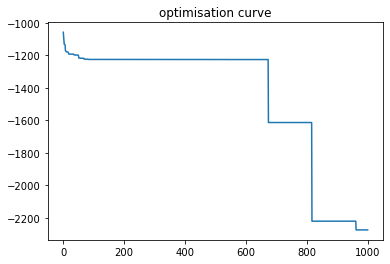

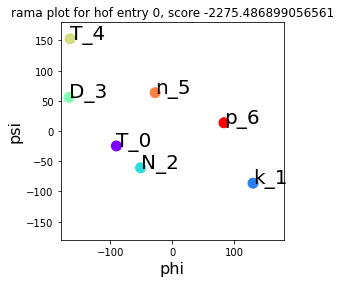

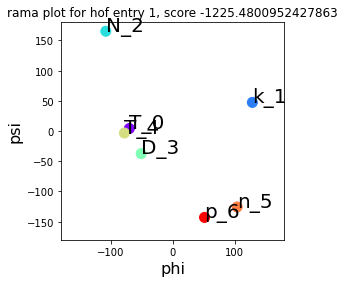

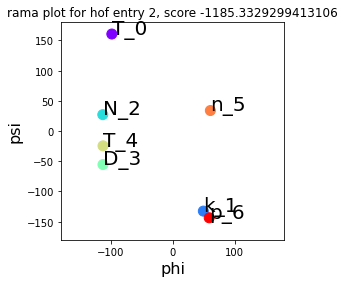

good was 59771, flip was 8038, bad cis was 1435
run took 1311 seconds


In [13]:
# 7.1 6be9
# trying this again to see if the various 'improvements' have improved the performance
# might need to find a way of checking geometry

k=7.1

t1 = time.time()
seq = macs[k]
pdb = pdbs[k]

RAM = 115
NSTEP = 1000

foo = optimise_mac(seq) #, rmsd_cut=25)
foo.build_start_mac()
foo.amber_setup()

foo.optimise(NSTEP, wp_len=20, hof_len=20, samplesize=20, rama_rmsd=RAM, n_permute=0, plot=True)

print(f"good was {foo.good}, flip was {foo.flip}, bad cis was {foo.cis_bad}")
t2 = time.time()
print(f'run took {int(t2 - t1)} seconds')

with open(f'/home/drew/Dropbox/Drew_Ongoing/GlasgowResearch/CyclicPeptides/baker_rebuilds/{seq}_{pdb}.pdb', 'a') as f:
    app.modeller.PDBFile.writeFile(foo.model.topology, foo.halloffame[0][1], file=f)

In [12]:

with open(f'/home/drew/Dropbox/Drew_Ongoing/GlasgowResearch/CyclicPeptides/baker_rebuilds/{seq}_BROKEN.pdb', 'a') as f:
    for h in foo.halloffame[:1]:
        app.modeller.PDBFile.writeFile(foo.model.topology, h[1], file=f)

In [ ]:
# find amino acid label name things to check for HIP

Starting rmsd is 4.2075892426168755
At iter 19900 best rmsd is 0.7276029952689317)
Managed only rmsd of 0.7356463780192297: resampling!
At iter 19900 best rmsd is 0.560016140093216))
Managed only rmsd of 0.5619088373884296: resampling!
At iter 19300 best rmsd is 0.05267040078716944)After 19324 iterations and 2 attempts best rmsd is 0.04971619759926737
initial energy is -384.4000038107906
optimising sequence pPYhPKDLq
 HOF at iter 399 is [-592.6879097112251, -486.5197365194372] best -592.6879097112251 worst -248.4216468076047 rama 115                                                                                                                                                                                                                           openmm not happy: Particle coordinate is nan
 HOF at iter 999 is [-594.6384202318009, -440.9797338098738, -305.362051080886, -191.04731639167176] best -594.6384202318009 worst -176.91051379712508 rama 119                                      

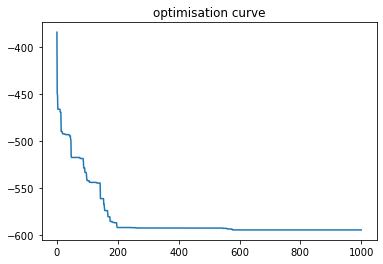

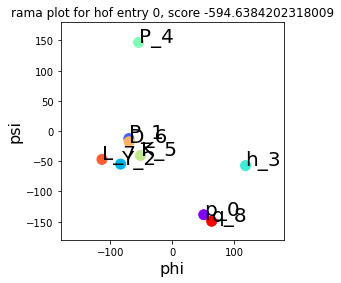

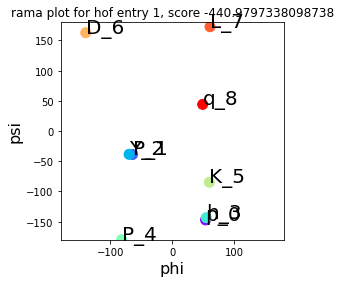

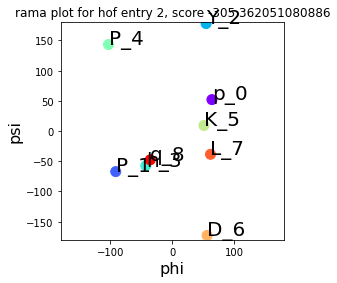

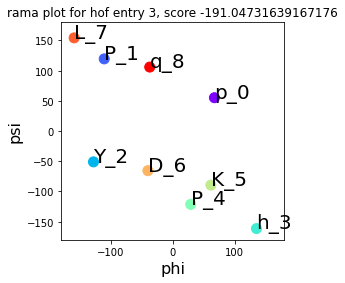

good was 72277, flip was 11643, bad cis was 2630
run took 2585 seconds


In [10]:
# 9.1 6beo 
# got 1.2 rmsd from -642 model (2000, 15) think also got lower than this, but it needs to be reproducible
# 1.9 off -634 (2000, 10) lower rama cutoff seems much worse in this case. 15 always cuts to 1 though!
# another 1.9 off -631.

## re-tooled the rmsd thing as it was a function of sequence length but should not have been
## now trying with pH set at 5.0 to see if we get HIP residue. Otherwise will specify directly.
## yes we do and 0.87 rmsd off 1000/115 run with score of -573 (score different as different bonds, presumably)
## 1.2 off -594 score with 1000/115

t1 = time.time()
seq = 'pPYhPKDLq' 

RAM = 115
NSTEP = 1000

foo = optimise_mac(seq) #, rmsd_cut=25)
foo.build_start_mac()
foo.amber_setup()

foo.optimise(NSTEP, wp_len=20, hof_len=20, samplesize=20, rama_rmsd=RAM, n_permute=5, plot=True)

print(f"good was {foo.good}, flip was {foo.flip}, bad cis was {foo.cis_bad}")
t2 = time.time()
print(f'run took {int(t2 - t1)} seconds')

with open(f'/home/drew/Dropbox/Drew_Ongoing/GlasgowResearch/CyclicPeptides/baker_rebuilds/{seq}_OBC2_am99sbnmr6_{NSTEP}_{RAM}.pdb', 'a') as f:
    app.modeller.PDBFile.writeFile(foo.model.topology, foo.halloffame[0][1], file=f)

Starting rmsd is 3.1201676943581798
At iter 13200 best rmsd is 0.05506314940826847)After 13241 iterations and 0 attempts best rmsd is 0.049422694185697495
initial energy is -2288.3006462860258
optimising sequence rQpqRePQ
 HOF at iter 1999 is [-2538.194073320864, -2488.5980515764686] best -2538.194073320864 worst -1746.749221263106 wp length 77                                                                                                                                                                                                                                 

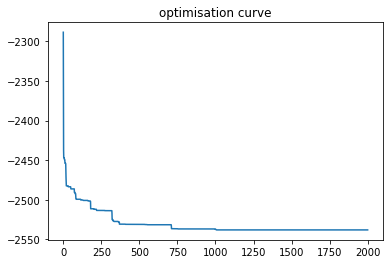

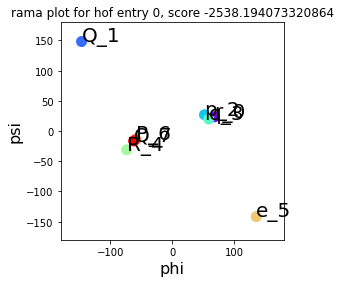

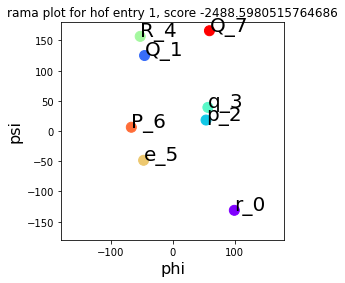

good was 126981, flip was 15543, bad cis was 3888
run took 3653 seconds


In [8]:
### 8.2 6ben
# if this looks good also with sbnmr then let's just do all of them and see what we get
# score of -2541 and rmsd of 0.45. The permute thing seems to really help it get unstuck maybe dial down from 5
# -2540 also gave an rmsd of 0.8. Actually looks pretty decent. Trying again with 2000 steps.
# haven't had any NAN positions- hypothesis these are due to Ile/Thr side chain code. Also amide flip code

t1 = time.time()
seq = 'rQpqRePQ' 

RAM = 15
NSTEP = 2000

foo = optimise_mac(seq) #, rmsd_cut=25)
foo.build_start_mac()
foo.amber_setup()

foo.optimise(NSTEP, wp_len=20, hof_len=10, samplesize=20, rama_rmsd=RAM, n_permute=5, plot=True)

print(f"good was {foo.good}, flip was {foo.flip}, bad cis was {foo.cis_bad}")
t2 = time.time()
print(f'run took {int(t2 - t1)} seconds')

with open(f'/home/drew/Dropbox/Drew_Ongoing/GlasgowResearch/CyclicPeptides/baker_rebuilds/{seq}_OBC2_am99sbnmr6_{NSTEP}_{RAM}.pdb', 'a') as f:
    for h in foo.halloffame[:4]:
        app.modeller.PDBFile.writeFile(foo.model.topology, h[1], file=f)

Starting rmsd is 4.151673283931118
At iter 7800 best rmsd is 0.05435230137778872)After 7893 iterations and 0 attempts best rmsd is 0.04891137961762925
initial energy is -986.1561062199064
optimising sequence TkNDTnp
 HOF at iter 757 is [-1224.9583786051908, -1190.4888552509726, -1182.161852963522, -1160.9784093566097, -1153.9182278860233, -1145.1414827503845, -1144.9651844961213, -1113.803420532214, -1100.6159601097236, -1091.5087722465585] best -1224.9583786051908 worst -853.5709375931522 wp length 46                          openmm not happy: Particle coordinate is nan
 HOF at iter 887 is [-1225.0897968940362, -1192.6331192049001, -1184.7657614676614, -1133.5269559203678, -1118.8168409273133, -1110.3495005780615, -1069.0149888588928, -1055.0004317438907, -1023.9623473726333] best -1225.0897968940362 worst -1002.9570027945142 wp length 49                                            openmm not happy: Particle coordinate is nan
 HOF at iter 999 is [-1225.1095623062943, -1193.550299276165

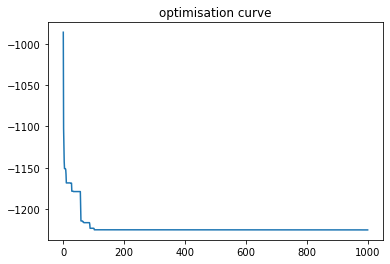

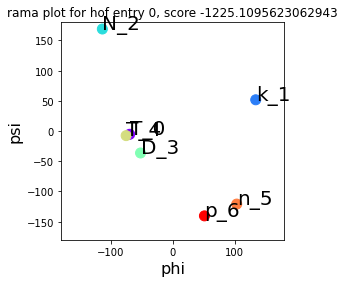

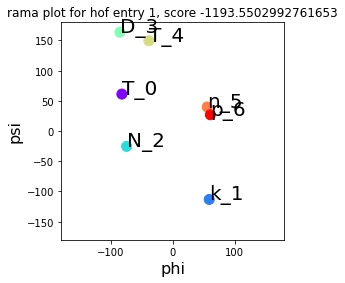

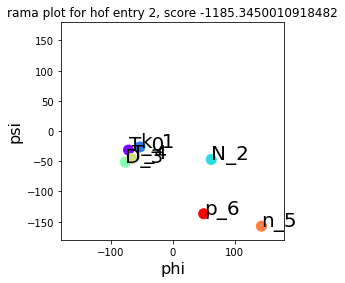

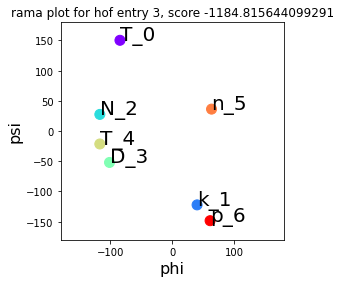

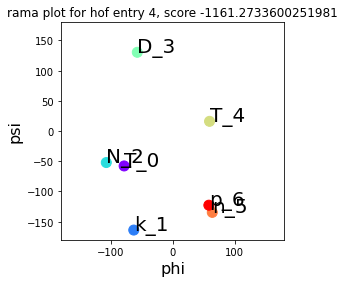

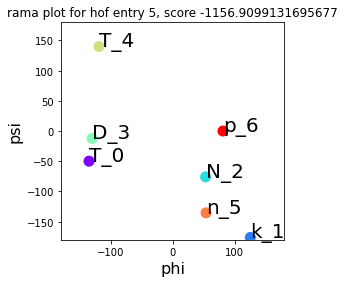

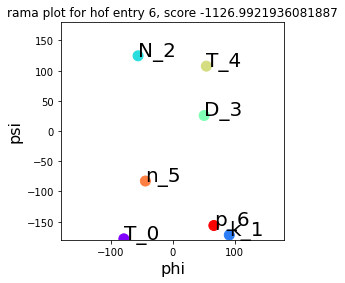

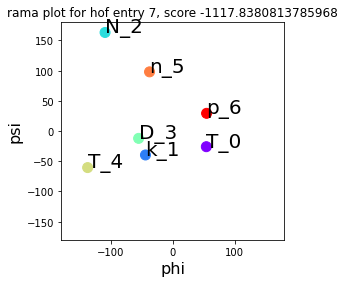

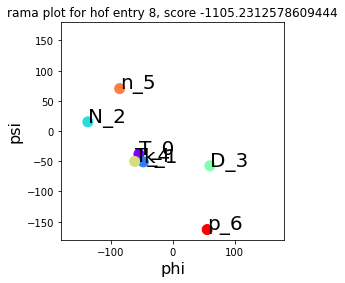

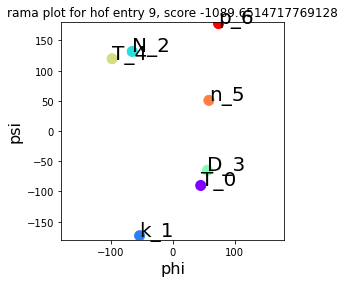

good was 70261, flip was 8927, bad cis was 1730
run took 1329 seconds


In [8]:
# 7.1 6be9
# trying with check that amber givest the same answer each time. Previous 500 step amber got -1206 score by step 100


t1 = time.time()
seq = 'TkNDTnp' 

RAM = 15
NSTEP = 1000

foo = optimise_mac(seq) #, rmsd_cut=25)
foo.build_start_mac()
foo.amber_setup()

foo.optimise(NSTEP, wp_len=20, hof_len=10, samplesize=20, rama_rmsd=RAM, n_permute=1, plot=True)

print(f"good was {foo.good}, flip was {foo.flip}, bad cis was {foo.cis_bad}")
t2 = time.time()
print(f'run took {int(t2 - t1)} seconds')

with open(f'/home/drew/Dropbox/Drew_Ongoing/GlasgowResearch/CyclicPeptides/baker_rebuilds/{seq}_OBC2_am99sbnmr2_{NSTEP}_{RAM}.pdb', 'a') as f:
    for h in foo.halloffame[:4]:
        app.modeller.PDBFile.writeFile(foo.model.topology, h[1], file=f)

Starting rmsd is 3.8231048889779604
At iter 15100 best rmsd is 0.05369173440632025))After 15174 iterations and 0 attempts best rmsd is 0.04955119794972065
initial energy is -615.2419276752378
optimising sequence hPdqseP
 HOF at iter 999 is [-697.7953462404026, -687.8581936519172, -683.0049305899818, -682.8000664158545, -680.6043179237846, -677.7678163713663, -668.5606471819692, -641.2054740922863, -550.7047357774329, -513.8811424706306] best -697.7953462404026 worst -298.9345118300838 wp length 96                         

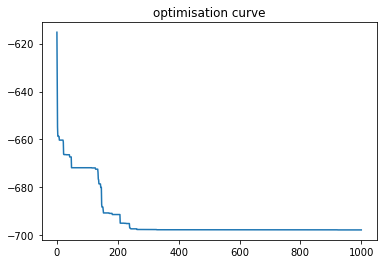

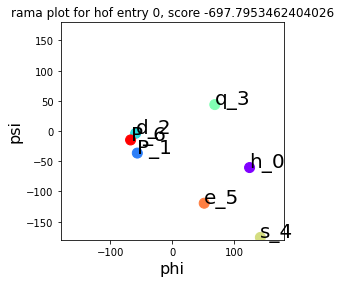

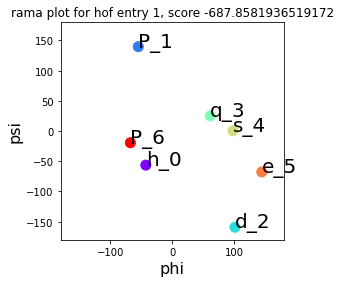

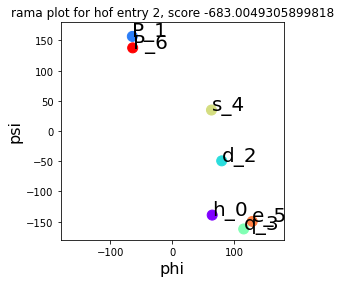

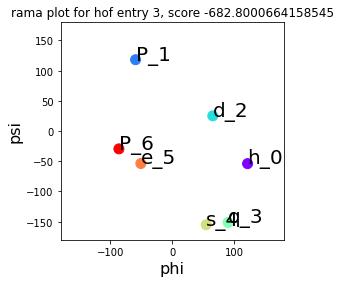

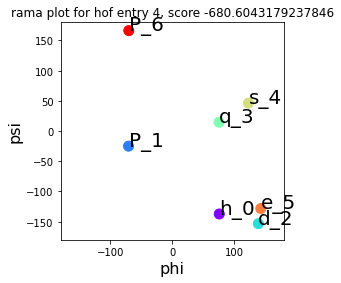

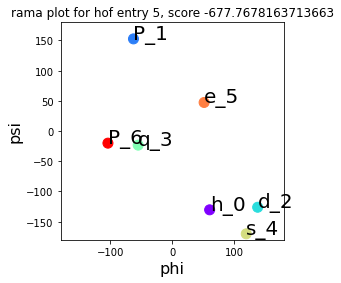

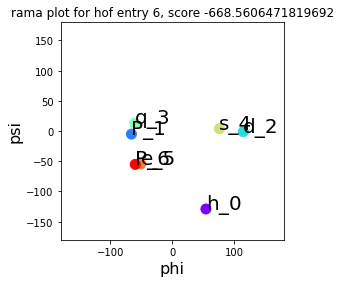

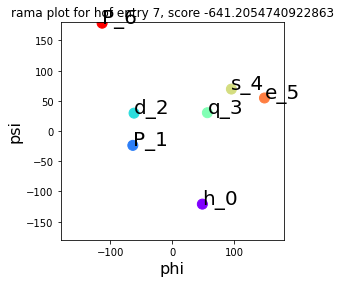

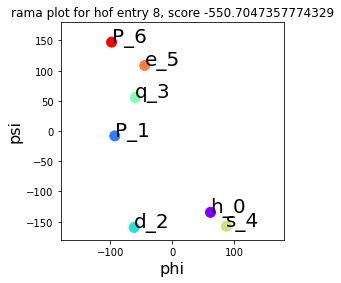

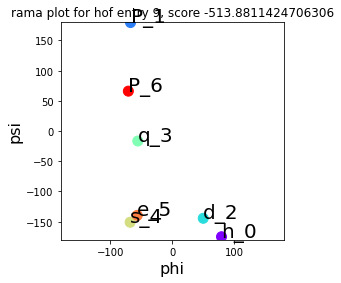

good was 69040, flip was 8481, bad cis was 1418
run took 1478 seconds


In [9]:
# 7.2 6bew 
# back to this first one to see if we do any better
# -700 ish with 20/2000 parameters gave actually rather decent looking 0.7 ish RMSD
# comfortably get 0.6, cf baker 0.8

RAM = 15
NSTEP = 1000

t1 = time.time()
seq = 'hPdqseP' 

foo = optimise_mac(seq) #, rmsd_cut=25)
foo.build_start_mac()
foo.amber_setup()

foo.optimise(NSTEP, wp_len=20, hof_len=10, samplesize=20, rama_rmsd=RAM, n_permute=1, plot=True)

print(f"good was {foo.good}, flip was {foo.flip}, bad cis was {foo.cis_bad}")
t2 = time.time()
print(f'run took {int(t2 - t1)} seconds')

with open(f'/home/drew/Dropbox/Drew_Ongoing/GlasgowResearch/CyclicPeptides/baker_rebuilds/{seq}_OBC2_am99sbnmr_{NSTEP}_{RAM}.pdb', 'a') as f:
    for h in foo.halloffame[:4]:
        app.modeller.PDBFile.writeFile(foo.model.topology, h[1], file=f)

Starting rmsd is 4.544525725993199
At iter 13400 best rmsd is 0.05130234114024875))After 13421 iterations and 0 attempts best rmsd is 0.04968269547079278
initial energy is -1695.4503878506398
optimising sequence DDPTprQq
 HOF at iter 999 is [-1926.9267336712123, -1851.2923211839434, -1686.8580619410109] best -1926.9267336712123 worst -1586.5956329009443 wp length 80                                                                                   

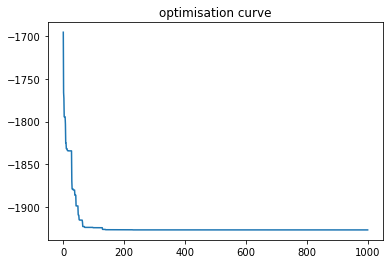

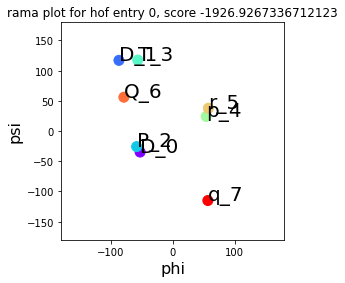

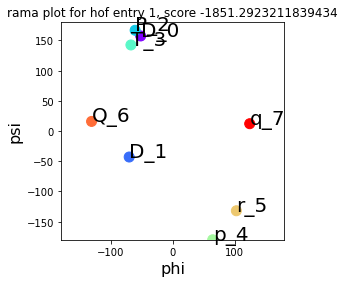

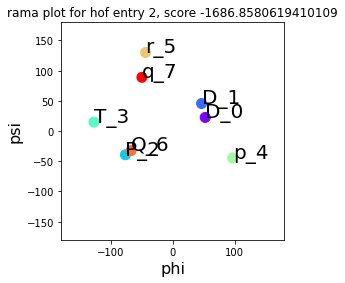

good was 64482, flip was 9144, bad cis was 1429
run took 1538 seconds


In [8]:
# 8.1 6be7
# SB NMR manages a perfect rmsd to model (0.1) with a score of -1927
# also 0.13 with score of -1900, though some rmsd's have been worse
# got those rmsd values with 1000 steps, which only takes about 15 mins to run
# going to see if 2000 steps, rmsd cut of 15 gives us more consistent scores.
# aberrant low scores due to flip routines being borked?
# check if it's associated with d or l residues, I/T or not
# could be down to dodgy strategy for flipping- maybe taking existing angles etc is dumb?

RAM = 15
NSTEP = 1000

t1 = time.time()
seq = 'DDPTprQq'

foo = optimise_mac(seq) #, rmsd_cut=25)
foo.build_start_mac()
foo.amber_setup()

foo.optimise(NSTEP, wp_len=20, hof_len=10, samplesize=20, rama_rmsd=RAM, n_permute=1, plot=True)

print(f"good was {foo.good}, flip was {foo.flip}, bad cis was {foo.cis_bad}")
t2 = time.time()
print(f'run took {int(t2 - t1)} seconds')

with open(f'/home/drew/Dropbox/Drew_Ongoing/GlasgowResearch/CyclicPeptides/baker_rebuilds/{seq}_OBC2_am99sbnmr5_{NSTEP}_{RAM}.pdb', 'a') as f:
    for h in foo.halloffame[:4]:
        app.modeller.PDBFile.writeFile(foo.model.topology, h[1], file=f)

In [16]:
# can we interrogate the simulation to see if the obc parameters took?
foo.simulation.topology.getNumBonds()

126

In [39]:
foo.simulation.context.setPositions(foo.halloffame[0][1])

In [40]:
forces = foo.simulation.system.getForces()

In [41]:
gbsa = forces[4]

In [42]:
gbsa.getSolventDielectric()

78.3

In [43]:
gbsa.getSoluteDielectric()

1.0

Starting rmsd is 3.468859257518117
At iter 12100 best rmsd is 0.0530458167709348))After 12150 iterations and 0 attempts best rmsd is 0.049656288501240806
initial energy is -1671.422017641925
optimising sequence DDPTprQq
 HOF at iter 499 is [-1959.2718693406205, -1922.1961785107121] best -1959.2718693406205 worst -1426.9367323660176 wp length 51                                                                                                                                                 

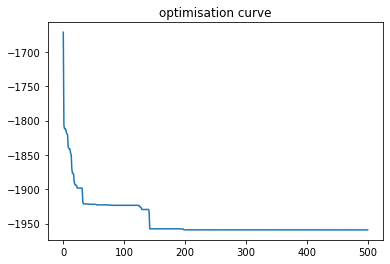

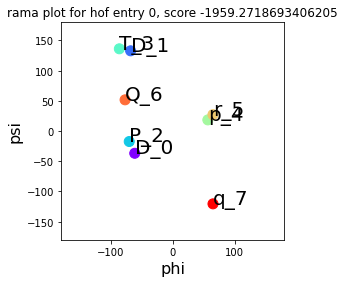

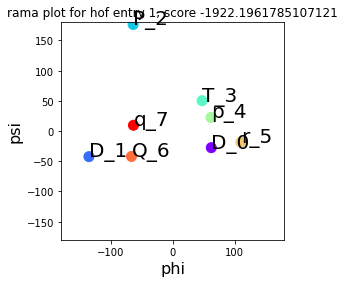

good was 18237, flip was 2299, bad cis was 446
run took 501 seconds


In [14]:
# 8.1 6be7

RAM = 15
NSTEP = 500

t1 = time.time()
seq = 'DDPTprQq'

foo = optimise_mac(seq) #, rmsd_cut=25)
foo.build_start_mac()
foo.amber_setup()

foo.optimise(NSTEP, wp_len=10, hof_len=10, samplesize=10, rama_rmsd=RAM, n_permute=1, plot=True)

print(f"good was {foo.good}, flip was {foo.flip}, bad cis was {foo.cis_bad}")
t2 = time.time()
print(f'run took {int(t2 - t1)} seconds')

with open(f'/home/drew/Dropbox/Drew_Ongoing/GlasgowResearch/CyclicPeptides/baker_rebuilds/{seq}_OBC2rpt2_am99sb_{NSTEP}_{RAM}.pdb', 'a') as f:
    for h in foo.halloffame[:4]:
        app.modeller.PDBFile.writeFile(foo.model.topology, h[1], file=f)

Starting rmsd is 4.2959237678704465
At iter 17900 best rmsd is 0.05886850316040735))After 17997 iterations and 0 attempts best rmsd is 0.049301073940976534
initial energy is -1735.1226187200505
optimising sequence DDPTprQq
 HOF at iter 1077 is [-1955.0268435195317, -1921.3713428543908] best -1955.0250325476682 worst -1699.6556099553127 wp length 17                                                                                                           61 wp length 37                         openmm not happy: Particle coordinate is nan
 HOF at iter 1284 is [-1955.0298267963788, -1921.3767167017893, -1827.4238971489935, -1815.5751546764373] best -1955.0274899596686 worst -1446.9207867561054 wp length 55                                                                openmm not happy: Particle coordinate is nan
 HOF at iter 1999 is [-1955.1387610309278, -1923.1571322078746, -1900.0018805095722, -1763.4848795942962] best -1955.1385128704032 worst -1694.6833276508708 wp length 50           

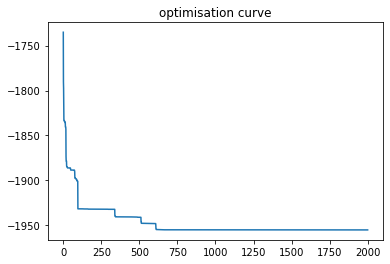

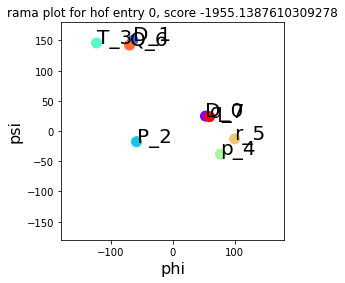

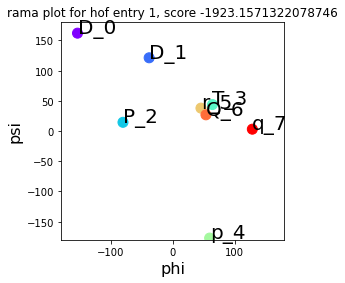

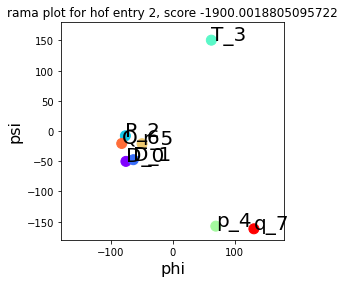

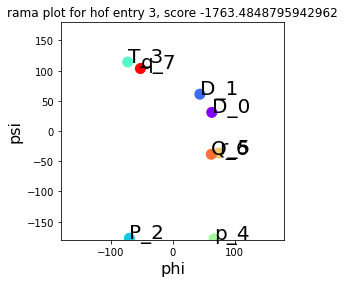

good was 74752, flip was 10198, bad cis was 1930
run took 4160 seconds


In [10]:
# 8.1 6be7

RAM = 15
NSTEP = 2000

t1 = time.time()
seq = 'DDPTprQq'

foo = optimise_mac(seq) #, rmsd_cut=25)
foo.build_start_mac()
foo.amber_setup()

foo.optimise(NSTEP, wp_len=10, hof_len=10, samplesize=10, rama_rmsd=RAM, n_permute=1, plot=True)

print(f"good was {foo.good}, flip was {foo.flip}, bad cis was {foo.cis_bad}")
t2 = time.time()
print(f'run took {int(t2 - t1)} seconds')

with open(f'/home/drew/Dropbox/Drew_Ongoing/GlasgowResearch/CyclicPeptides/baker_rebuilds/{seq}_am99sb_{NSTEP}_{RAM}.pdb', 'a') as f:
    for h in foo.halloffame[:4]:
        app.modeller.PDBFile.writeFile(foo.model.topology, h[1], file=f)

Starting rmsd is 3.634789312815314
At iter 2700 best rmsd is 0.06573298467431725)After 2777 iterations and 0 attempts best rmsd is 0.04907179384974089
initial energy is -845.6651776080769
optimising sequence QDPpKtd
 HOF at iter 1747 is [-952.9201016143288, -951.9616838657895, -948.0802652003276, -942.9580353357553, -878.8003928588901, -812.4996045991388, -751.2430463555673] best -952.9200869636372 worst -698.6138104394324 wp length 23                                           4508 wp length 31                        openmm not happy: Particle coordinate is nan
 HOF at iter 1999 is [-952.9212229901987, -951.9616838657895, -948.6007143576112, -942.9580353357553, -923.8935581636416, -923.7681310089224, -904.1071847207259, -877.2480041836118, -876.5648858711508, -807.3613741582076] best -952.9212229901987 worst -298.0879548310879 wp length 52                        

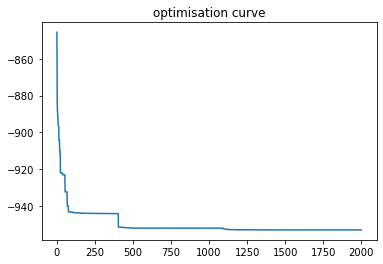

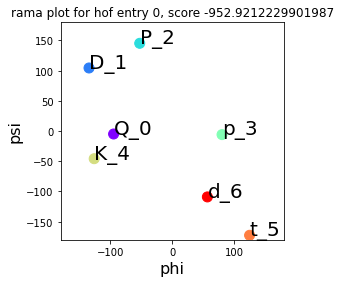

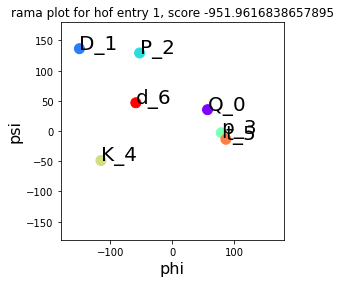

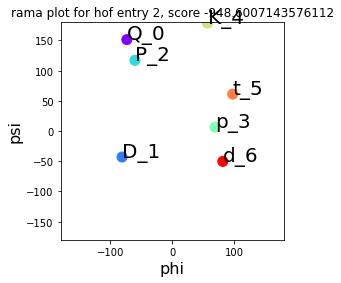

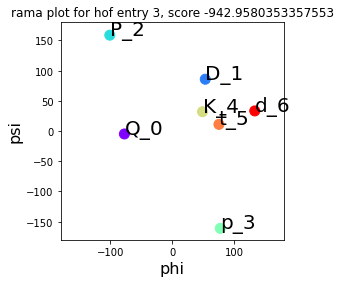

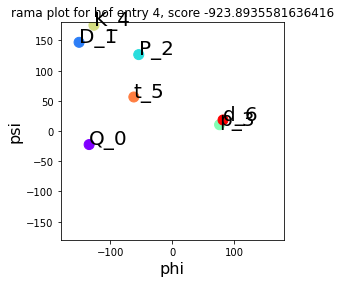

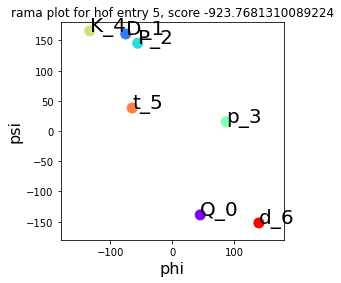

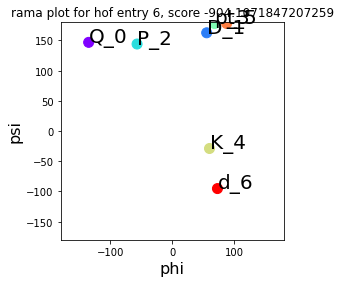

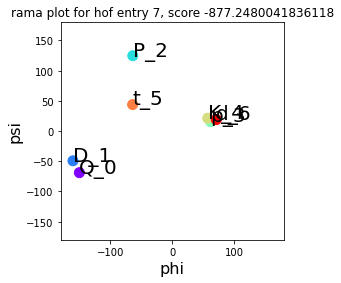

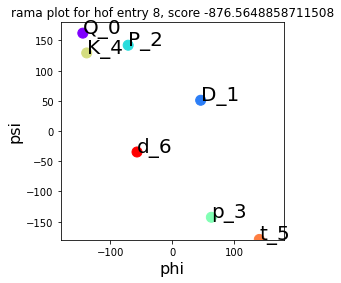

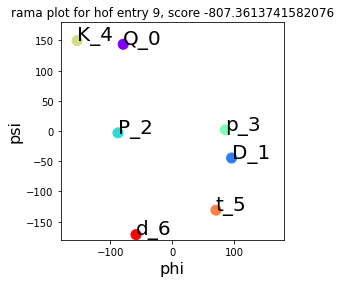

good was 85545, flip was 9819, bad cis was 2007
run took 3902 seconds


In [9]:
# 7.3 6bf3/6bf5

RAM = 15
NSTEP = 2000

t1 = time.time()
seq = 'QDPpKtd'

foo = optimise_mac(seq) #, rmsd_cut=25)
foo.build_start_mac()
foo.amber_setup()

foo.optimise(NSTEP, wp_len=10, hof_len=10, samplesize=10, rama_rmsd=RAM, n_permute=1, plot=True)

print(f"good was {foo.good}, flip was {foo.flip}, bad cis was {foo.cis_bad}")
t2 = time.time()
print(f'run took {int(t2 - t1)} seconds')

with open(f'/home/drew/Dropbox/Drew_Ongoing/GlasgowResearch/CyclicPeptides/baker_rebuilds/{seq}_am99sb_{NSTEP}_{RAM}.pdb', 'a') as f:
    for h in foo.halloffame[:4]:
        app.modeller.PDBFile.writeFile(foo.model.topology, h[1], file=f)

Starting rmsd is 3.7769837679659735
At iter 14800 best rmsd is 0.05112822157511315))After 14814 iterations and 0 attempts best rmsd is 0.049589649481883755
initial energy is -573.6029940235413
optimising sequence hPdqseP
 HOF at iter 1999 is [-760.2987678647381] best -760.2967554480795 worst -579.9702416038936 wp length 46                                                                                 

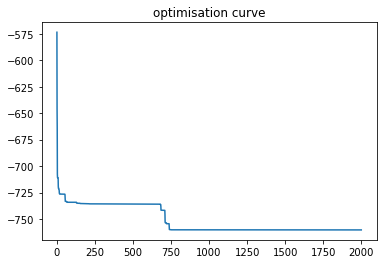

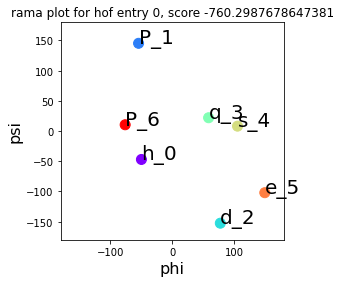

good was 68154, flip was 9822, bad cis was 2575
run took 3723 seconds


In [8]:
# 7.2 6bew 

RAM = 20
NSTEP = 2000

t1 = time.time()
seq = 'hPdqseP' 

foo = optimise_mac(seq) #, rmsd_cut=25)
foo.build_start_mac()
foo.amber_setup()

foo.optimise(NSTEP, wp_len=10, hof_len=10, samplesize=10, rama_rmsd=RAM, n_permute=1, plot=True)

print(f"good was {foo.good}, flip was {foo.flip}, bad cis was {foo.cis_bad}")
t2 = time.time()
print(f'run took {int(t2 - t1)} seconds')

with open(f'/home/drew/Dropbox/Drew_Ongoing/GlasgowResearch/CyclicPeptides/baker_rebuilds/{seq}_am99sb_{NSTEP}_{RAM}.pdb', 'a') as f:
    for h in foo.halloffame[:4]:
        app.modeller.PDBFile.writeFile(foo.model.topology, h[1], file=f)

Starting rmsd is 2.490056118460655
At iter 19900 best rmsd is 0.0984483135794491))
Managed only rmsd of 0.09602507046696693: resampling!
At iter 12000 best rmsd is 0.05046362241167478)After 12010 iterations and 1 attempts best rmsd is 0.04480093037388762
initial energy is -1158.0900927551093
optimising sequence TkNDTnp
 HOF at iter 188 is [-1271.440535699212] best -1271.440535699212 worst -1061.3744195092784 wp length 35                                                                   openmm not happy: Particle coordinate is nan
 HOF at iter 1988 is [-1273.9470138931893, -1127.7722029184063] best -1273.9457019120557 worst -1069.7758880005333 wp length 32                                                                openmm not happy: Particle coordinate is nan
 HOF at iter 1999 is [-1273.950268477871] best -1273.949126176114 worst -717.3859135780117 wp length 46                                               

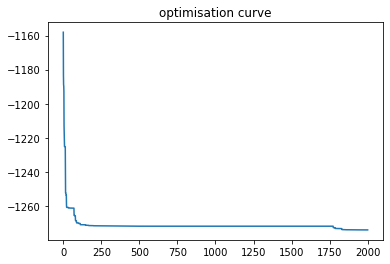

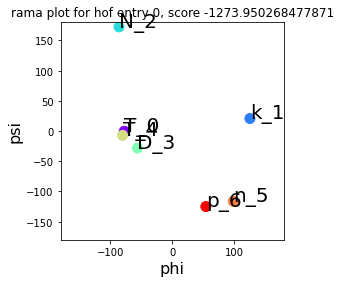

good was 70766, flip was 8790, bad cis was 1586
run took 3378 seconds


In [20]:
# 7.1 6be9
# trying with check that amber givest the same answer each time. Previous 500 step amber got -1206 score by step 100

RAM = 20
NSTEP = 2000

t1 = time.time()
seq = 'TkNDTnp' 
foo = optimise_mac(seq) #, rmsd_cut=25)
foo.build_start_mac()
foo.amber_setup()

foo.optimise(NSTEP, wp_len=10, hof_len=10, samplesize=10, rama_rmsd=RAM, n_permute=1, plot=True)

print(f"good was {foo.good}, flip was {foo.flip}, bad cis was {foo.cis_bad}")
t2 = time.time()
print(f'run took {int(t2 - t1)} seconds')

with open(f'/home/drew/Dropbox/Drew_Ongoing/GlasgowResearch/CyclicPeptides/baker_rebuilds/{seq}_am99sb_{NSTEP}_{RAM}.pdb', 'a') as f:
    for h in foo.halloffame[:4]:
        app.modeller.PDBFile.writeFile(foo.model.topology, h[1], file=f)

Starting rmsd is 4.215375035145707
At iter 4500 best rmsd is 0.06523597458923701)After 4582 iterations and 0 attempts best rmsd is 0.04841411597589666
initial energy is -1896.736544244879
optimising sequence TkNDTnp
 HOF at iter 159 is [-2154.492119120239, -2128.7499424430907, -2109.0251174571763, -2101.7269534817297, -2097.673376025372, -2087.7346673887573, -2086.720715712746, -2085.6384807520926, -2081.2044115717213, -2077.1680562703223] best -2154.4899818393505 worst -1644.5307611426979 wp length 56                         openmm not happy: Particle coordinate is nan
 HOF at iter 726 is [-2166.5004037846543, -2128.9117158416693, -2109.17219488142, -2106.5160450920966, -2106.016313566956, -2100.8397538704485, -2100.373474603393, -2097.6769964062896, -2097.2026405103056, -2086.7849704843884] best -2166.4978481996513 worst -1777.364051409651 wp length 24                            openmm not happy: Particle coordinate is nan
 HOF at iter 1883 is [-2166.5004037846543, -2128.911715841669

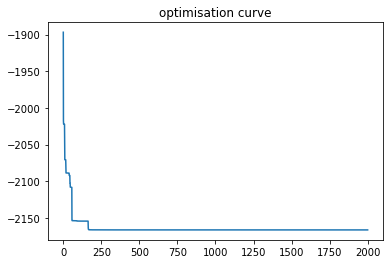

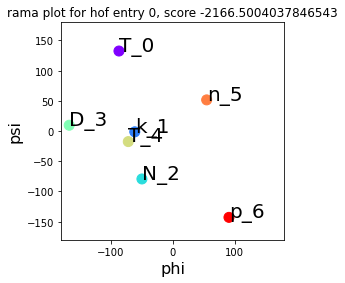

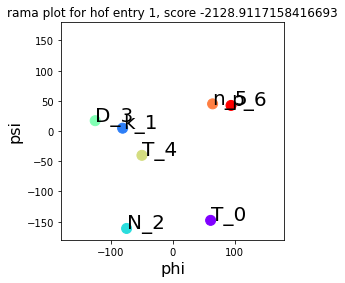

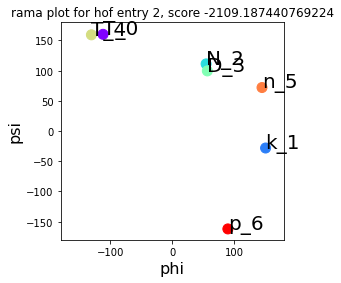

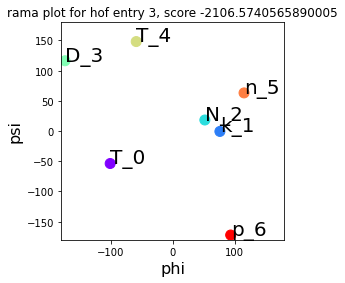

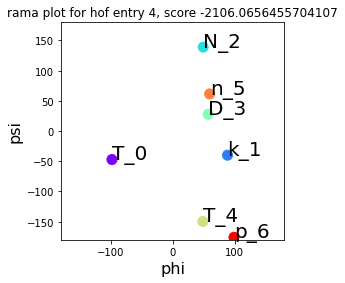

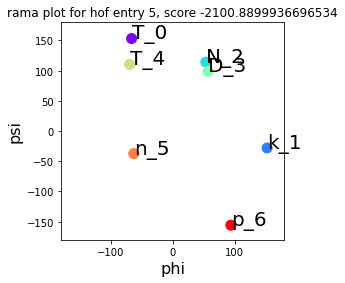

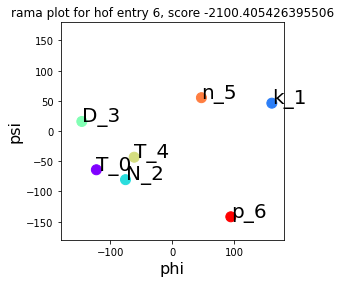

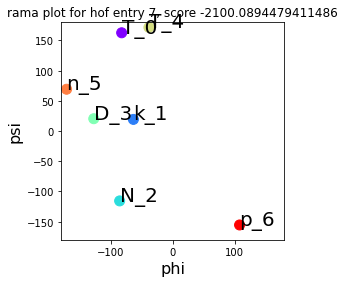

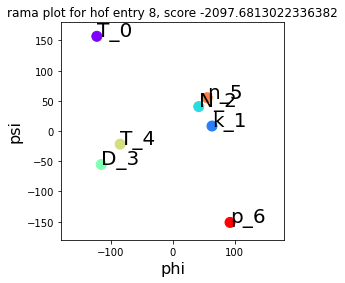

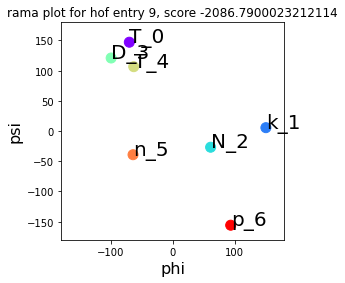

good was 86899, flip was 12326, bad cis was 2342
run took 5521 seconds


In [18]:
# 7.1 6be9
# trying with check that amber givest the same answer each time. Previous 500 step amber got -1206 score by step 100

RAM = 10
NSTEP = 2000

t1 = time.time()
seq = 'TkNDTnp' 
foo = optimise_mac(seq) #, rmsd_cut=25)
foo.build_start_mac()
foo.amber_setup()

foo.optimise(NSTEP, wp_len=10, hof_len=10, samplesize=10, rama_rmsd=RAM, n_permute=1, plot=True)

print(f"good was {foo.good}, flip was {foo.flip}, bad cis was {foo.cis_bad}")
t2 = time.time()
print(f'run took {int(t2 - t1)} seconds')

with open(f'/home/drew/Dropbox/Drew_Ongoing/GlasgowResearch/CyclicPeptides/baker_rebuilds/{seq}_am10_{NSTEP}_{RAM}.pdb', 'a') as f:
    for h in foo.halloffame[:4]:
        app.modeller.PDBFile.writeFile(foo.model.topology, h[1], file=f)

Starting rmsd is 3.929889480893863
At iter 4600 best rmsd is 0.052058217770604626)After 4655 iterations and 0 attempts best rmsd is 0.04985076704630124
initial energy is -1038.0847638210385
optimising sequence TkNDTnp
 HOF at iter 189 is [-1198.9206913202952, -1196.987848670486, -1196.357448370335, -1189.1214361430934, -1186.0036216671406, -1181.56089825451, -1179.386013563422, -1177.7426370566004, -1171.920454173483, -1167.731001610467] best -1198.9206913202952 worst -853.7568724363445 wp length 51                               openmm not happy: Particle coordinate is nan
 HOF at iter 261 is [-1203.772972965536, -1200.4228563983543, -1197.7327936121317, -1197.1286453099128, -1186.0917878989615, -1186.055231323369, -1181.7196810898604, -1179.645010288269, -1179.413181031156, -1178.7644648305638] best -1203.772972965536 worst -1059.8418358305694 wp length 23                            openmm not happy: Particle coordinate is nan
 HOF at iter 483 is [-1214.9742025624664, -1213.3191866309

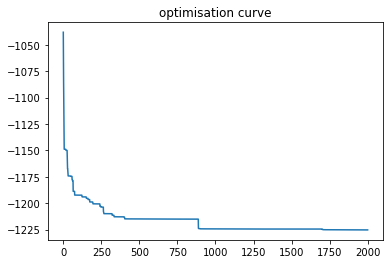

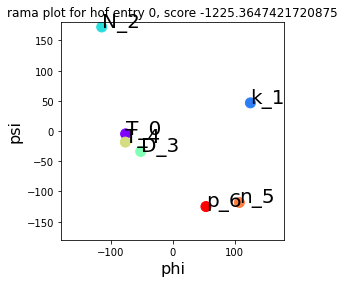

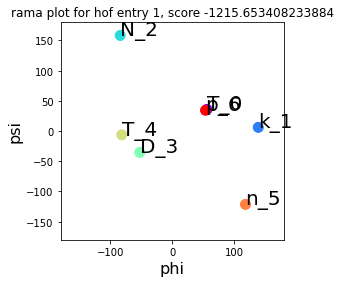

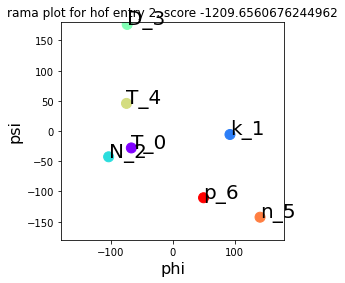

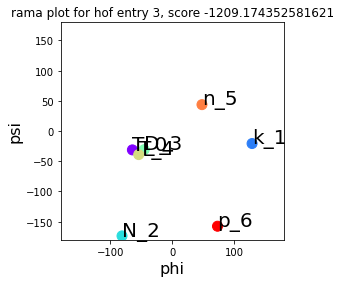

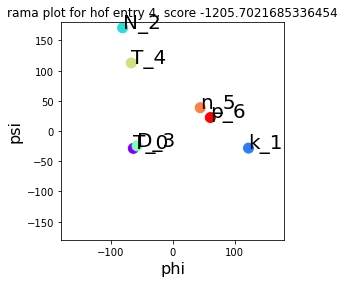

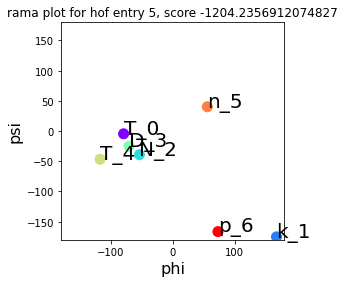

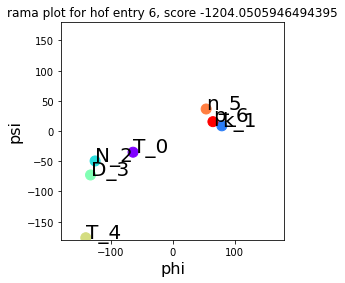

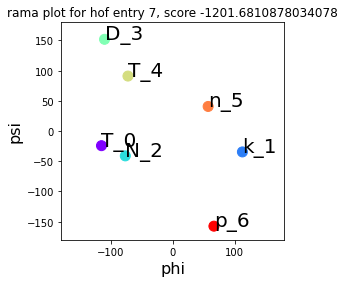

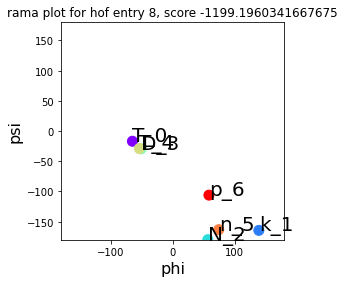

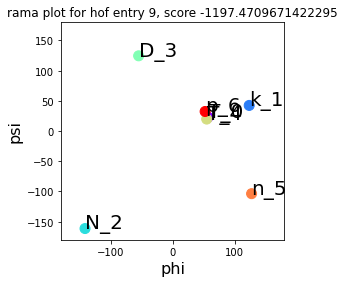

good was 86099, flip was 10187, bad cis was 2268
run took 3989 seconds


In [16]:
# 7.1 6be9
# trying with check that amber givest the same answer each time. Previous 500 step amber got -1206 score by step 100

RAM = 10
NSTEP = 2000

t1 = time.time()
seq = 'TkNDTnp' 
foo = optimise_mac(seq) #, rmsd_cut=25)
foo.build_start_mac()
foo.amber_setup()

foo.optimise(NSTEP, wp_len=10, hof_len=10, samplesize=10, rama_rmsd=RAM, n_permute=1, plot=True)

print(f"good was {foo.good}, flip was {foo.flip}, bad cis was {foo.cis_bad}")
t2 = time.time()
print(f'run took {int(t2 - t1)} seconds')

with open(f'/home/drew/Dropbox/Drew_Ongoing/GlasgowResearch/CyclicPeptides/baker_rebuilds/{seq}_am99nmr_{NSTEP}_{RAM}.pdb', 'a') as f:
    for h in foo.halloffame[:4]:
        app.modeller.PDBFile.writeFile(foo.model.topology, h[1], file=f)

Starting rmsd is 2.4876371299424256
At iter 10000 best rmsd is 0.05637556514746366)After 10035 iterations and 0 attempts best rmsd is 0.04874626202192872
initial energy is -1035.9323166972636
optimising sequence TkNDTnp
 HOF at iter 1999 is [-1219.047137952031, -1203.5777362887645, -1201.119818134482, -1200.9030247687583, -1200.3612430855035, -1198.2585187513573, -1196.503714941098, -1195.2174590951322, -1188.0363521359345, -1171.6964872342735] best -1219.045302122329 worst -1043.3581212706852 wp length 57                           

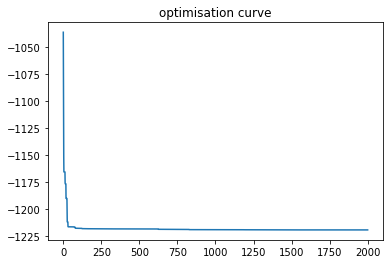

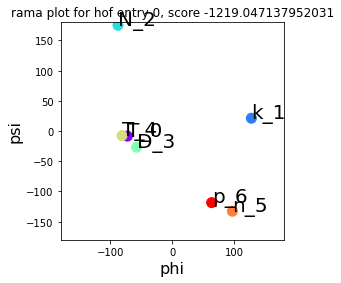

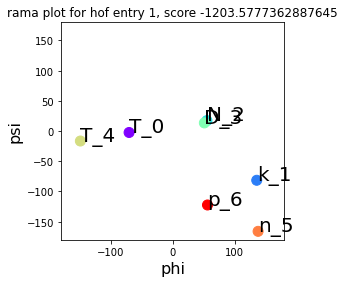

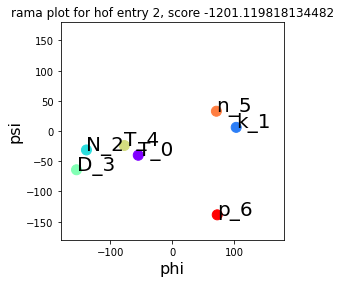

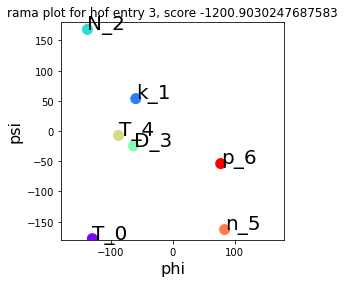

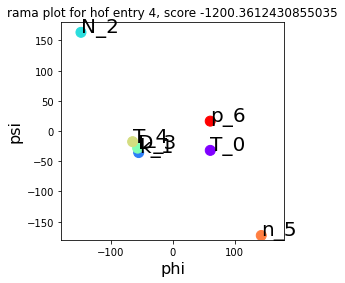

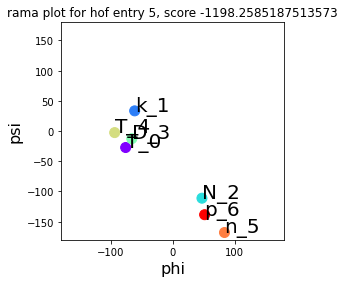

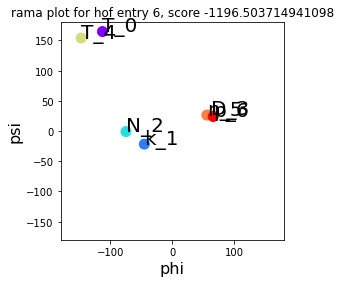

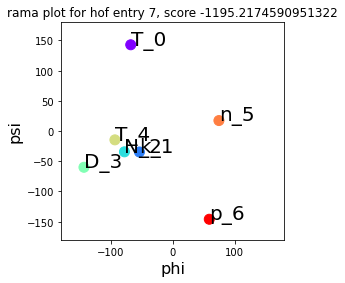

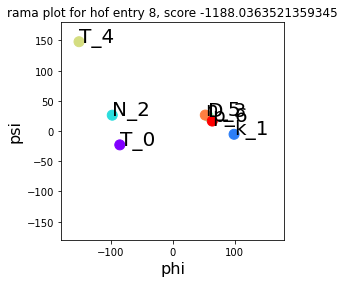

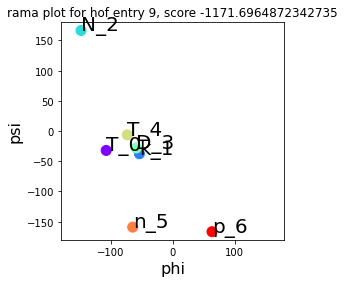

good was 86476, flip was 9765, bad cis was 2058
run took 3868 seconds


In [14]:
# 7.1 6be9
# trying with check that amber givest the same answer each time. Previous 500 step amber got -1206 score by step 100

RAM = 12
NSTEP = 2000

t1 = time.time()
seq = 'TkNDTnp' 
foo = optimise_mac(seq) #, rmsd_cut=25)
foo.build_start_mac()
foo.amber_setup()

foo.optimise(NSTEP, wp_len=10, hof_len=10, samplesize=10, rama_rmsd=RAM, n_permute=1, plot=True)

print(f"good was {foo.good}, flip was {foo.flip}, bad cis was {foo.cis_bad}")
t2 = time.time()
print(f'run took {int(t2 - t1)} seconds')

with open(f'/home/drew/Dropbox/Drew_Ongoing/GlasgowResearch/CyclicPeptides/baker_rebuilds/{seq}_am99sbildn_{NSTEP}_{RAM}.pdb', 'a') as f:
    for h in foo.halloffame[:4]:
        app.modeller.PDBFile.writeFile(foo.model.topology, h[1], file=f)

In [ ]:
# should prob look at doing alignment here automagically

In [59]:
foo.working_pop[-1][0]

-1139.5418971980062

Starting rmsd is 2.5305105800724514
At iter 4300 best rmsd is 0.05284270703608791))After 4304 iterations and 0 attempts best rmsd is 0.046414799977835694
initial energy is -403.3176358347346
optimising sequence hPdqseP
 HOF at iter 999 is [-699.1811824175061, -696.5693463131266, -692.5373382595762] best -699.1801991773644 rmsd cut left 56                       

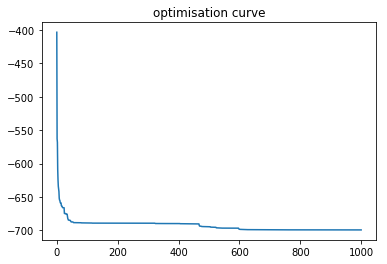

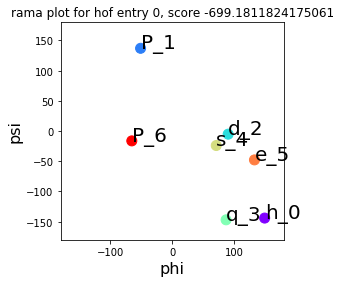

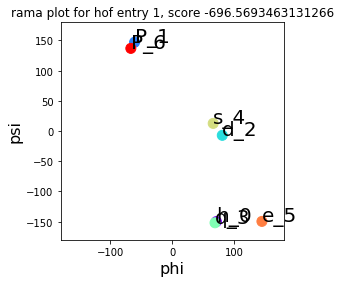

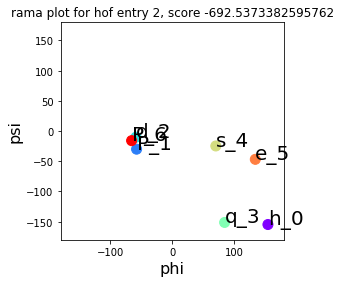

good was 55915, flip was 13093, bad cis was 1180
run took 6808 seconds


In [9]:
# 7.2 6bew 
t1 = time.time()
seq = 'hPdqseP' 
foo = optimise_mac(seq)
foo.build_start_mac()

foo.amber_setup()

foo.optimise(1000, wp_len=15, hof_len=3, samplesize=40, start_rama_rmsd = 5, end_rama_rmsd = 5,
             n_permute=5, plot=True)

print(f"good was {foo.good}, flip was {foo.flip}, bad cis was {foo.cis_bad}")
t2 = time.time()
print(f'run took {int(t2 - t1)} seconds')

with open(f'/home/drew/Dropbox/Drew_Ongoing/GlasgowResearch/CyclicPeptides/baker_rebuilds/{seq}_5_5.pdb', 'a') as f:
    for h in foo.halloffame:
        app.modeller.PDBFile.writeFile(foo.model.topology, h[1], file=f)

Starting rmsd is 3.17119234222962
At iter 10600 best rmsd is 0.05066490044338349))After 10626 iterations and 0 attempts best rmsd is 0.049422039521176325
initial energy is -614.0491365599794
optimising sequence QDPpKtd
 HOF at iter 507 is [-887.0033641388893, -876.6564283950568, -875.8356933330704] best -887.0033641388893 rmsd cut left 57                       openmm not happy: Particle coordinate is nan
 HOF at iter 999 is [-899.5652237189281, -880.7705606332806, -875.9871144489379] best -899.5652237189281 rmsd cut left 55                       

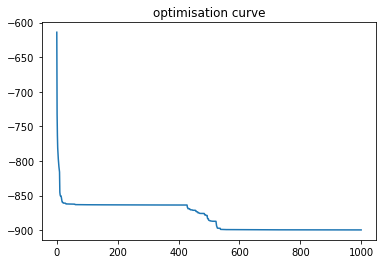

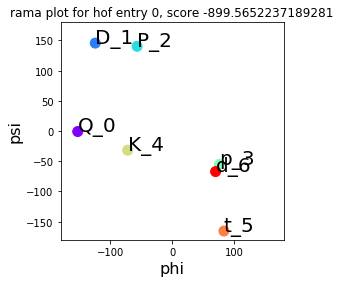

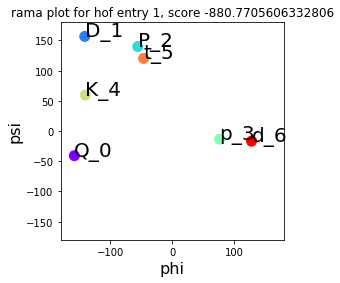

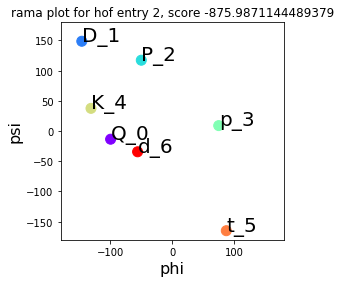

good was 54217, flip was 15688, bad cis was 2798
run took 6784 seconds


In [10]:
# 7.3 6bf3/6bf5
t1 = time.time()
seq = 'QDPpKtd' 
foo = optimise_mac(seq)
foo.build_start_mac()

foo.amber_setup()

foo.optimise(1000, wp_len=15, hof_len=3, samplesize=40, start_rama_rmsd = 5, end_rama_rmsd = 5,
             n_permute=5, plot=True)

print(f"good was {foo.good}, flip was {foo.flip}, bad cis was {foo.cis_bad}")
t2 = time.time()
print(f'run took {int(t2 - t1)} seconds')

with open(f'/home/drew/Dropbox/Drew_Ongoing/GlasgowResearch/CyclicPeptides/baker_rebuilds/{seq}_5_5.pdb', 'a') as f:
    for h in foo.halloffame:
        app.modeller.PDBFile.writeFile(foo.model.topology, h[1], file=f)

Starting rmsd is 4.32005237272823
At iter 19900 best rmsd is 0.42260391283255067)
Managed only rmsd of 0.41871917034248396: resampling!
At iter 7000 best rmsd is 0.05393945888125765)After 7065 iterations and 1 attempts best rmsd is 0.04895857285593885
initial energy is -1659.8649599905118
optimising sequence DDPTprQq
 HOF at iter 253 is [-1892.099171375462, -1872.3460657779242, -1842.92161617512] best -1892.099171375462 rmsd cut left 51                           openmm not happy: Particle coordinate is nan
 HOF at iter 465 is [-1892.2957522557358, -1872.3460657779242, -1867.2436056347851] best -1892.2957522557358 rmsd cut left 60                       openmm not happy: Particle coordinate is nan
 HOF at iter 562 is [-1892.3432297607974, -1872.3460657779242, -1867.2436056347851] best -1892.3432297607974 rmsd cut left 53                       openmm not happy: Particle coordinate is nan
 HOF at iter 912 is [-1892.4338938323658, -1872.3460657779242, -1869.3702327606861] best -1892.4335579

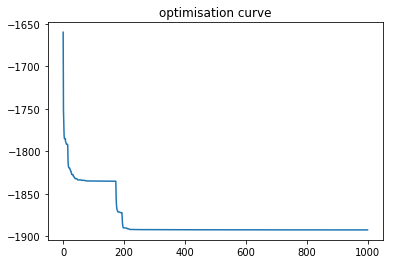

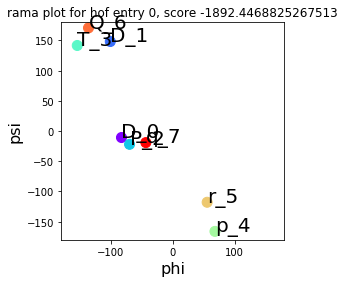

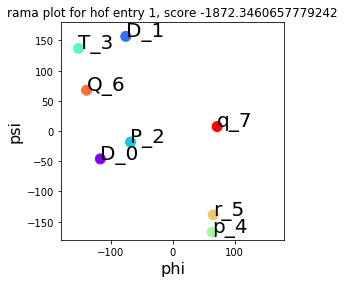

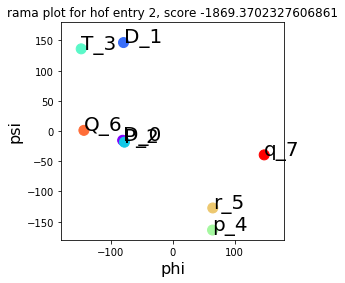

good was 54522, flip was 20509, bad cis was 2482
run took 7155 seconds


In [8]:
# 8.1 6be7 
t1 = time.time()
seq = 'DDPTprQq' 
foo = optimise_mac(seq)
foo.build_start_mac()

foo.amber_setup()

foo.optimise(1000, wp_len=15, hof_len=3, samplesize=40, start_rama_rmsd = 5, end_rama_rmsd = 5,
             n_permute=5, plot=True)

print(f"good was {foo.good}, flip was {foo.flip}, bad cis was {foo.cis_bad}")
t2 = time.time()
print(f'run took {int(t2 - t1)} seconds')

with open(f'/home/drew/Dropbox/Drew_Ongoing/GlasgowResearch/CyclicPeptides/baker_rebuilds/{seq}_5_5.pdb', 'a') as f:
    for h in foo.halloffame:
        app.modeller.PDBFile.writeFile(foo.model.topology, h[1], file=f)

Starting rmsd is 3.50883027270637
At iter 19900 best rmsd is 0.36893124705195934)
Managed only rmsd of 0.36719570295700804: resampling!
At iter 15000 best rmsd is 0.06009207568690305)After 15083 iterations and 1 attempts best rmsd is 0.049781820615622745
initial energy is -2265.2521465582067
optimising sequence rQpqRePQ
 HOF at iter 999 is [-2598.658549312997, -2579.100252049183, -2557.8676406339673] best -2598.658549312997 rmsd cut left 56                          

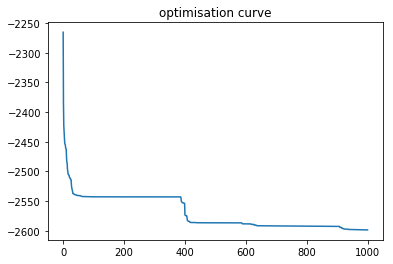

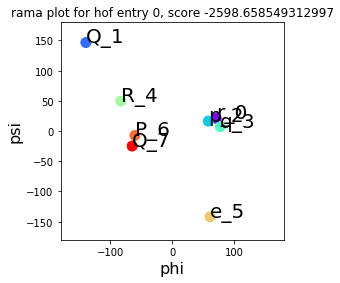

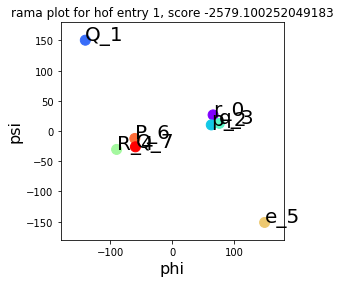

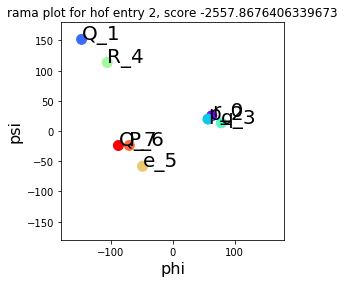

good was 54678, flip was 17741, bad cis was 2411
run took 8269 seconds


In [9]:
# 8.2 6ben 
t1 = time.time()
seq = 'rQpqRePQ' 
foo = optimise_mac(seq)
foo.build_start_mac()

foo.amber_setup()

foo.optimise(1000, wp_len=15, hof_len=3, samplesize=40, start_rama_rmsd = 5, end_rama_rmsd = 5,
             n_permute=5, plot=True)

print(f"good was {foo.good}, flip was {foo.flip}, bad cis was {foo.cis_bad}")
t2 = time.time()
print(f'run took {int(t2 - t1)} seconds')

with open(f'/home/drew/Dropbox/Drew_Ongoing/GlasgowResearch/CyclicPeptides/baker_rebuilds/{seq}_5_5.pdb', 'a') as f:
    for h in foo.halloffame:
        app.modeller.PDBFile.writeFile(foo.model.topology, h[1], file=f)

Starting rmsd is 4.566310939784014
At iter 19900 best rmsd is 0.1422458370376552))
Managed only rmsd of 0.12332049282500676: resampling!
At iter 19900 best rmsd is 0.11250455117589862)
Managed only rmsd of 0.10978459370620144: resampling!
At iter 16400 best rmsd is 0.05177208148871948))After 16469 iterations and 2 attempts best rmsd is 0.04916923233150076
initial energy is -325.36854207018223
optimising sequence pPYhPKDLq
 HOF at iter 999 is [-618.126768192209, -609.7399453622784, -604.639025196298] best -618.126768192209 rmsd cut left 57                           

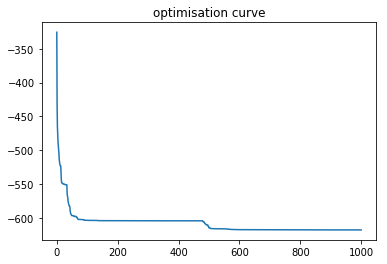

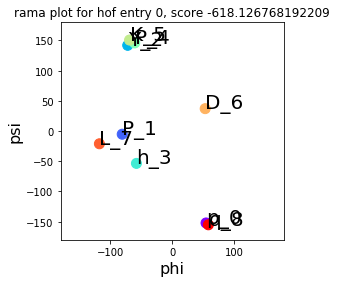

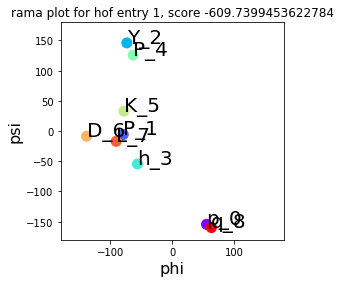

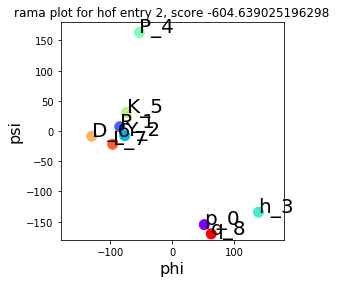

good was 54094, flip was 18968, bad cis was 2959
run took 9319 seconds


In [10]:
# 9.1 6beo 
t1 = time.time()
seq = 'pPYhPKDLq' 
foo = optimise_mac(seq)
foo.build_start_mac()

foo.amber_setup()

foo.optimise(1000, wp_len=15, hof_len=3, samplesize=40, start_rama_rmsd = 5, end_rama_rmsd = 5,
             n_permute=5, plot=True)

print(f"good was {foo.good}, flip was {foo.flip}, bad cis was {foo.cis_bad}")
t2 = time.time()
print(f'run took {int(t2 - t1)} seconds')

with open(f'/home/drew/Dropbox/Drew_Ongoing/GlasgowResearch/CyclicPeptides/baker_rebuilds/{seq}_5_5.pdb', 'a') as f:
    for h in foo.halloffame:
        app.modeller.PDBFile.writeFile(foo.model.topology, h[1], file=f)